# Place cell identification from calcium imaging data
Tested on Python 3.9.18 / 3.10.8, with Caiman 1.10.4


Revised from the paper 'A probabilistic framework for decoding behavior from calcium imaging data'. You can also refer to the Matlab version of this notebook here: www.github.com/etterguillaume/CaImDecoding

In [ ]:
import os
import logging
from __future__ import annotations
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import re
import random

import seaborn as sns
import pynapple as nap
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy.ndimage import label
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm

source = Path(r"E:\PC92_COPY")

add_frames = True
slice_no = 1   # starts from 1
slice_size = 10000

# Load methods

In [ ]:
def plot_tcurve (tcurves, save_name = None, Vmin=0.00, Vmax=0.08, W=8, H=6):
    df = tcurves.T  # Transpose to get neurons as rows

    # Plot the heatmap
    plt.figure(figsize=(W, H))
    sns.set(font_scale=0.3)

    HM = sns.heatmap(
        df,
        vmin=Vmin,
        vmax=Vmax,
        square=False,
        cmap="Blues",
        cbar_kws={'label': 'ΔF/F'}
    )

    HM.set(
        xlabel="Position Bins",
        ylabel="Neuron Index",
        title="Place Cell Tuning Curves"
    )

    HM.set_xticks([0, df.shape[1] - 1])
    HM.set_xticklabels(["0", "400"])

    plt.tight_layout()
    if save_name != None:
        plt.savefig(output_path / f"{save_name}.png", dpi=300, bbox_inches="tight")
        print_to_log(f"Heatmap saved as {save_name}.png")

    plt.show()

def filter_goodcells(Primary_cell_index, iscell, gate=0.4):
   
    valid_idx = []
    
    for cid in Primary_cell_index:

        probability = iscell[cid][1]
       
        # 检查stat条件
        if probability > gate:
            valid_idx.append(cid)
        else:
            continue
            
    return valid_idx

def ROI_QC(Primary_cell_index, stat):
   
    valid_idx = []
    
    for cid in Primary_cell_index:

        temp_x, temp_y = stat[cid]["med"]
        compact = stat[cid]["compact"]
        aspect = stat[cid]["compact"]
       
        # 检查stat条件
        if 150> stat[cid]["npix"] > 30:
            if temp_x < 492 and temp_y < 492:
                 if temp_x > 20 and temp_y > 20:
                        if compact < 1.11 and aspect < 1.26:
                            valid_idx.append(cid)
                        else: 
                                continue
            
    return valid_idx



def WriteIscell(index, data_source, name):

    iscell_path = data_source / "suite2p" / "plane0" / "iscell.npy"

    data = np.load(iscell_path)
    data[:,0] = 0
    data[index, 0] = 1

    # print(data[:,0])
    iscell_target = data_source / "outputs" / f"{name}.npy"
    np.save(iscell_target, data)
    print_to_log(f"{name}.npy is written")




# Gaussian smoothing 

def smoothAngularTuningCurves(tuning_curves, sigma=1):
    smoothed_data = np.zeros_like(tuning_curves.values)
    for i in range(tuning_curves.shape[1]):
        # 使用 mode='wrap' 处理环形数据
        smoothed_data[:, i] = gaussian_filter1d(
            tuning_curves.iloc[:, i].values, 
            sigma=sigma, 
            mode='wrap'  # 关键修改：环形卷积
        )
    return pd.DataFrame(
        data=smoothed_data, 
        index=tuning_curves.index, 
        columns=tuning_curves.columns
    )

def identify_place_fields(smoothcurves, neuron_idx, threshold_ratio=0.25, min_true_len=3, max_true_len=30):
    """
    计算指定神经元的place fields，并返回布尔类型数组。
    
    参数：
    smoothcurves (np.array): 所有神经元的调谐曲线数组，形状为 (num_neurons, num_bins)。
    neuron_idx (int): 要计算place fields的神经元索引。
    threshold_ratio (float): 阈值比例，用于确定place fields的阈值。
    min_true_len (int): 最小的连续True长度，用于识别有效的place fields。
    max_true_len (int): 最大的连续True长度，用于识别有效的place fields。
    
    返回值：
    np.array: 布尔类型数组，标记出指定神经元的place fields。
    """
    
    neuron_tuning_curves = smoothcurves[neuron_idx]
    
    # 计算峰值和基线值
    peak = np.max(neuron_tuning_curves)
    sorted_values = np.sort(neuron_tuning_curves)
    low_20_percent = sorted_values[:int(0.2 * len(sorted_values))]
    baseline = np.mean(low_20_percent)
    
    # 计算阈值（基线 + 0.25 * (峰值 - 基线)）
    threshold = baseline + (peak - baseline) * threshold_ratio
    
    # 找到超过阈值的点
    potential = neuron_tuning_curves > threshold
    
    # 使用 Scipy 识别连续的True区域
    labeled, num_features = label(potential)
    
    # 创建布尔数组存储位置场
    place_fields = np.zeros_like(potential, dtype=bool)
    
    for feature in range(1, num_features + 1):
        indices = np.where(labeled == feature)[0]
        field_length = len(indices)
        if min_true_len <= field_length < max_true_len:
            place_fields[indices] = True
    
    return place_fields



def FilterShuffle_parallel(FilterTime_place_cell_index, transients, is_running, Filtered_Position, epochs, bin_indices,
                           FilterField_thresholdRatio, FilterMean_threshold, FilterTime_thresholdRatio,
                           nsample=1000, window=50, bin_num=80, num_frames=36030, n_jobs=18):
    """
    并行版本的 FilterShuffle：对每个神经元并行执行 shuffle/bootstrap 检验
    """
    def process_one_neuron(neuron_idx):
        # --------------------------
        # 1. 提取当前神经元的钙信号
        # --------------------------
        temp_trace = transients[:, neuron_idx]

        # --------------------------
        # 2. Shuffle 该神经元的信号
        # --------------------------
        shuffled_vectors = shuffle(temp_trace, nsample, window)

        # --------------------------
        # 3. 构造 shuffle 后的 TsdFrame
        # --------------------------
        temp_shuffle_transients = nap.TsdFrame(
            t=np.arange(num_frames) / 30,
            d=shuffled_vectors.T,
            time_support=transients.time_support
        )

        # --------------------------
        # 4. 计算 shuffle 后的调谐曲线
        # --------------------------
        shuffle_tuning_curves = nap.compute_1d_tuning_curves_continuous(
            temp_shuffle_transients[is_running],
            feature=Filtered_Position[is_running],
            nb_bins=bin_num
        )
        shuffle_smoothcurves = smoothAngularTuningCurves(shuffle_tuning_curves, sigma=1)

        # --------------------------
        # 5. 对每个 shuffle 后的神经元（共 nsample 个），运行 place_cell_identification
        # --------------------------
        count = 0
        for i in range(temp_shuffle_transients.shape[1]):  # 遍历每个 shuffle 版本的神经元
            if place_cell_identification(
                neuron_idx=i,
                tuning_curves=shuffle_smoothcurves,
                Filtered_Position=Filtered_Position,
                epochs=epochs,
                transients=temp_shuffle_transients,
                FilterField_thresholdRatio=FilterField_thresholdRatio,
                FilterMean_threshold=FilterMean_threshold,
                FilterTime_thresholdRatio=FilterTime_thresholdRatio,
                bin_indices=bin_indices,
                num_frames=num_frames
            ):
                count += 1

        # --------------------------
        # 6. 计算 p 值并判断是否显著
        # --------------------------
        p_value = count / nsample
        if p_value < 0.05:
            return neuron_idx  # 通过筛选，返回该神经元索引
        else:
            return None  # 未通过，返回 None

    # ================================
    # 并行处理所有神经元
    # ================================
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_one_neuron)(neuron_idx)
        for neuron_idx in tqdm(FilterTime_place_cell_index, desc="FilterShuffle (parallel)")
    )

    # 过滤掉 None，只保留通过检验的神经元
    place_cells_index = [neuro_idx for neuro_idx in results if neuro_idx is not None]
    return place_cells_index


def place_cell_identification(
    neuron_idx,
    tuning_curves,
    transients,
    Filtered_Position,
    FilterField_thresholdRatio,
    FilterMean_threshold,
    FilterTime_thresholdRatio,
    epochs,
    bin_indices,
    frame_rate=30.0,  # 默认帧率，可根据实际情况调整
    num_frames=36030
):
    """
    潜在位置细胞识别

    参数：
    - neuron_idx (int): 神经元的索引。
    - tuning_curves (pd.DataFrame 或 np.ndarray): 所有神经元的平滑调谐曲线，形状为 (神经元数, 位置数)。
    - transients (pd.DataFrame 或 np.ndarray): 瞬时响应数据，维度为 (时间, 神经元)。
    - epochs (dict): epoch 字典，每个 epoch 包含 'start' 和 'end' 时间（以秒为单位）。
    - Filtered_Position (object): 具有 `values` 属性的过滤位置对象，形状为 (时间,)。
    - identify_place_fields (function): 用于识别位置场的函数，接受 `tuning_curves` 和 `neuron_idx` 作为参数，返回布尔数组。
    - snr_ratio (float): 信噪比阈值比例，默认 7。
    - track_traversed_threshold_ratio (float): 遍历次数的阈值比例，默认 0.33。
    - frame_rate (float): 帧率，用于将时间转换为帧索引，默认 1.0。
    - num_frames (int, 可选): 总帧数。如果未提供，将从 `Filtered_Position` 中推断。

    返回：
    - bool: 如果神经元通过所有过滤步骤，返回 `True`；否则返回 `False`。
    """
    
    # 第一步：识别潜在位置场
    tc = tuning_curves[neuron_idx]
    potential_place_fields = identify_place_fields(tuning_curves, neuron_idx=neuron_idx, threshold_ratio=FilterField_thresholdRatio)
    
    # 如果没有符合条件的位置场，返回 False
    if not np.any(potential_place_fields):
        return False


    masks = potential_place_fields 
    # extract each continuous field-range from the boolean mask
    field_ranges = []
    in_field = False
    for pos, val in enumerate(masks):
        if val and not in_field:
            start = pos; in_field = True
        elif not val and in_field:
            end = pos; in_field = False
            field_ranges.append((start, end))
    if in_field:
        field_ranges.append((start, len(masks)))

    all_field_mask = np.zeros_like(tc, dtype=bool)
    for start_bin, end_bin in field_ranges:
        all_field_mask[start_bin:end_bin] = True
    out_data = tc.iloc[~all_field_mask]


    epochs_frames = [
    (
        max(int(np.floor(start * frame_rate)), 0),
        min(int(np.ceil(end * frame_rate)), num_frames)
    )
    # 直接通过 .start 和 .end 属性获取时间区间
    for start, end in zip(epochs.start, epochs.end)
    ]
    
    threshold = len(epochs_frames) * FilterTime_thresholdRatio #FilterTime Threshold ratio
    neuron_activity = transients[:, neuron_idx] > 0  # shape: (num_frames,)

    # 3) check mean_inside > 7 * mean_outside for _any_ field
    for start_bin, end_bin in field_ranges:
        valid_mean = False
        valid_time = False
        # positional slice with .iloc
        in_data  = tc.iloc[start_bin:end_bin]   # positional slice, OK
        n_bins = len(tc)
        mask_this_field = np.zeros(n_bins, dtype=bool)
        mask_this_field[start_bin:end_bin] = True
        # out_data = tc.iloc[~mask_this_field]

        mean_in  = np.nanmean(in_data)
        mean_out = np.nanmean(out_data)
        if mean_in >= mean_out * FilterMean_threshold:
            valid_mean = True
        else:
            continue

        traversals = 0
        for start, end in epochs_frames:
            positions_epoch = bin_indices.values[start:end]
            activity_epoch = neuron_activity[start:end]

            # 判断是否落在当前 field 范围内
            in_field = (positions_epoch >= start_bin) & (positions_epoch <= end_bin)
            significant_activity = activity_epoch & in_field
            
            if np.any(significant_activity):
                traversals += 1
            

        if traversals > threshold:
            valid_time = True

        if (valid_mean and valid_time): 
            return True
    
    # 第四步：检查跨 epoch 的遍历次数是否超过阈值
    # 预处理 epochs，转换为帧索引并确保在有效范围内
    # epochs_frames = [
    #     (
    #         max(int(np.floor(epoch['start'] * frame_rate)), 0),
    #         min(int(np.ceil(epoch['end'] * frame_rate)), num_frames)
    #     )
    #     for epoch in epochs.values()      

def shuffle(vector, nsample, window):
    
    """
    Efficiently shuffles the input vector by splitting it into segments and shuffling these segments without replacement,
    ensuring that the mean and total sum of the sequence remain unchanged after shuffling.
    
    Parameters:
    - vector: One-dimensional numpy array
    - nsample: Number of shuffles
    - window: Size of each segment
    
    Returns:
    - vectors: Two-dimensional numpy array with shape (nsample, len(vector))
    """
    vector = np.asarray(vector)
    if vector.ndim != 1:
        raise ValueError("Input vector must be one-dimensional.")
    if not isinstance(nsample, int) or nsample <= 0:
        raise ValueError("nsample must be a positive integer.")
    if not isinstance(window, int) or window <= 0:
        raise ValueError("window must be a positive integer.")
    
    n = len(vector)
    nsegment = n // window
    remainder = n % window

    if nsegment == 0:
        raise ValueError("Window size is larger than the length of the vector.")
    segments = vector[:nsegment * window].reshape(nsegment, window)

    # Preallocate the shuffled vectors
    shuffled_vectors = np.empty((nsample, nsegment, window), dtype=vector.dtype)

    for i in range(nsample):
        rng = np.random.RandomState(seed=i)  # 固定种子，基于 shuffle 索引
        perm = rng.permutation(nsegment)     # 生成确定性的随机排列
        shuffled_vectors[i] = segments[perm]

    shuffled_vectors = shuffled_vectors.reshape(nsample, -1)

    # If there is a remainder, append the remaining part of the original vector to each shuffled sample
    if remainder > 0:
        remainder_part = vector[nsegment * window:]
        shuffled_vectors = np.hstack([shuffled_vectors, np.tile(remainder_part, (nsample, 1))])
        shuffled_vectors = shuffled_vectors[:, :n]

    return shuffled_vectors


def organize_place_cells_by_peak(tuning_curves, place_cell_indices, min_peak_width=3):
    """
    根据位置细胞调谐曲线的峰值位置进行排序（修复维度错误版本）
    
    参数:
    tuning_curves (pd.DataFrame|np.ndarray): 形状为 (num_bins, num_neurons) 的调谐曲线
    place_cell_indices (list): 需要排序的位置细胞索引列表
    min_peak_width (int): 最小峰值宽度(单位：位置bin数)
    
    返回:
    sorted_indices (np.ndarray): 按峰值位置排序后的细胞索引
    """
    # 输入验证与转换
    if isinstance(tuning_curves, pd.DataFrame):
        curve_array = tuning_curves.values.T  # 转换为 (neurons, bins)
    else:
        curve_array = np.asarray(tuning_curves)
    
    # 确保输入为二维数组
    if curve_array.ndim != 2:
        raise ValueError("输入数据应为二维数组 (neurons × bins)")
    
    peak_data = []
    
    for idx in place_cell_indices:
        # 提取单个神经元的调谐曲线
        curve = curve_array[idx, :]  # 关键修正点：明确提取第idx个神经元的曲线
        
        # 峰值检测逻辑
        peaks = []
        in_peak = False
        peak_start = 0
        
        # 遍历每个位置bin (i为bin索引)
        for i in range(1, len(curve)-1):
            # 当前bin的值与前、后bin比较
            prev_val = curve[i-1]
            curr_val = curve[i]
            next_val = curve[i+1]
            
            # 检测上升沿（允许平台区）
            if (curr_val > prev_val) and (curr_val >= next_val) and not in_peak:
                peak_start = i
                in_peak = True
            
            # 检测下降沿
            if in_peak and (curr_val < next_val or i == len(curve)-2):
                if i - peak_start >= min_peak_width:
                    # 在峰值窗口内找最大值位置
                    peak_window = curve[peak_start:i+1]
                    peak_pos = peak_start + np.argmax(peak_window)
                    peaks.append(peak_pos)
                in_peak = False
        
        # 主峰选择
        if peaks:
            main_peak = peaks[np.argmax([curve[p] for p in peaks])]
            peak_data.append( (main_peak, idx) )
    
    # 按峰值位置排序
    peak_data.sort(key=lambda x: x[0])
    
    return np.array([p[1] for p in peak_data], dtype=int)

def generate_and_save_heatmap(neuron_index, all_tuning_curves, save_dir):
    try:
        results_list = []

        # 使用预先计算的调谐曲线
        for epoch_smoothcurves in all_tuning_curves:
            data = epoch_smoothcurves[neuron_index]
            results_list.append(data.values)

        results_df = pd.DataFrame(results_list)
        
        # 检查数据
        logging.info(f"Neuron {neuron_index} - Data Shape: {results_df.shape}")
        logging.info(results_df.head())

        plt.figure(figsize=(16, 8))
        sns.heatmap(results_df, cmap='Spectral_r', annot=False)  # 移除 vmin 和 vmax
        plt.xlabel('Bins')
        plt.ylabel('Epochs')
        plt.title(f'Tuning Curves Heatmap for Neuron {neuron_index}')
        plt.tight_layout()  # 优化布局

        # 构建完整的文件路径
        file_name = f"neuron{neuron_index}.png"
        file_path = os.path.join(save_dir, file_name)
        
        logging.info(f"Saving heatmap to: {file_path}")

        # 检查保存目录是否存在，如果不存在则创建
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # 保存图像为 PNG 文件
        plt.savefig(file_path, format='png')
        plt.close()

    except Exception as e:
        logging.error(f"Error processing neuron {neuron_index}: {e}", exc_info=True)


        

def inspect_cell(
    neuron_idx,
    tuning_curves,
    transients,
    Filtered_Position,
    epochs,
    is_running,
    bin_indices,
    FilterField_thresholdRatio,
    FilterMean_threshold,
    FilterTime_thresholdRatio,
    frame_rate=30.0,  # 默认帧率，可根据实际情况调整
    num_frames=36030
):
   


    # 如果未提供总帧数，从 Filtered_Position 推断
    if num_frames is None:
        num_frames = len(Filtered_Position.values)

  
    
    # 第一步：识别潜在位置场
    neuron_tuning_curve = tuning_curves[neuron_idx]

    # Calculate peak and baseline values
    peak = np.max(neuron_tuning_curve)
    sorted_values = np.sort(neuron_tuning_curve)
    low_20_percent = sorted_values[:int(0.2 * len(sorted_values))]
    baseline = np.mean(low_20_percent)
    print(f"peak = {peak}")
    print(f"baseline = {baseline}")
    
    # Caclulate threshold and filter spatial bin
    threshold = baseline + (peak - baseline) * 0.25
    potential = neuron_tuning_curve > threshold
    place_fields = np.zeros_like(potential, dtype=bool)
    
    # find place field width > 15cm and <150cm
    in_field = False
    start_idx = 0
    true_count = 0
    field_bin = []
   
    
    for idx, value in enumerate(potential):
       
        if value:
            if not in_field:
                # start 
                in_field = True
                field_bin.append(idx)
                start_idx = idx
            true_count += 1
        else:
            if in_field:
                # end
                if 3 <= true_count: 
                    place_fields[start_idx:idx] = True
                in_field = False
                field_bin.append(idx-1)
                true_count = 0

    # if in_field and 3 < true_count < 30:
    if in_field and 3 <= true_count < 30:
        place_fields[start_idx:] = True
        field_bin.append(len(potential))
    
    print(f"potential fields boundary is {field_bin}")
    
    if np.sum(place_fields) != 0:
        print("FilterField pass")

    else: print("FilterField not pass")
        
    
    tc = tuning_curves[neuron_idx]
    
    # 第三步：计算场内和场外的平均值，判断是否满足 SNR 条件
    # mean_infield = np.mean(place_field_tc)
    # mean_outfield = np.mean(neuron_tuning_curve[~potential_place_fields])
    # print(f"mean_infield = {mean_infield}, mean_outfield = {mean_outfield}")

    masks = identify_place_fields(tuning_curves, neuron_idx=neuron_idx)

    # 3) extract each continuous field-range from the boolean mask
    field_ranges = []
    in_field = False
    for pos, val in enumerate(masks):
        if val and not in_field:
            start = pos; in_field = True
        elif not val and in_field:
            end = pos; in_field = False
            field_ranges.append((start, end))
    if in_field:
        field_ranges.append((start, len(masks)))
    print(f"Identified {len(field_ranges)} place fields: {field_ranges}")

    all_field_mask = np.zeros_like(tc, dtype=bool)
    for start_bin, end_bin in field_ranges:
        all_field_mask[start_bin:end_bin] = True
    out_data = tc.iloc[~all_field_mask]

    epochs_frames = [
    (
        max(int(np.floor(start * frame_rate)), 0),
        min(int(np.ceil(end * frame_rate)), num_frames)
    )
    # 直接通过 .start 和 .end 属性获取时间区间
    for start, end in zip(epochs.start, epochs.end)
    ]


    # 4) check mean_inside > 7 * mean_outside for _any_ field
    for field_idx, (start_bin, end_bin) in enumerate(field_ranges):
        # positional slice with .iloc
        in_data  = tc.iloc[start_bin:end_bin]   # positional slice, OK
        n_bins = len(tc)
        mask_this_field = np.zeros(n_bins, dtype=bool)
        mask_this_field[start_bin:end_bin] = True
        # out_data = tc.iloc[~mask_this_field]

        mean_in  = np.nanmean(in_data)
        mean_out = np.nanmean(out_data)

        print(f"field {field_idx}: mean_in = {mean_in}, mean_out = {mean_out}")

        if mean_in >= mean_out * 7:
            print(f"FilterMean for field {field_idx} pass")
        else:
            print(f"FilterMean for field {field_idx} not pass")
            continue

        neuron_activity = transients[:, neuron_idx] > 0  # shape: (num_frames,)

        traversals = 0
        for start, end in epochs_frames:
            positions_epoch = bin_indices.values[start:end]
            activity_epoch = neuron_activity[start:end]

            # 判断是否落在当前 field 范围内
            in_field = (positions_epoch >= start_bin) & (positions_epoch <= end_bin)
            significant_activity = activity_epoch & in_field
            
            if np.any(significant_activity):
                traversals += 1

        threshold = len(epochs_frames) * 0.33 #FilterTime Threshold ratio
        print(f"Field {field_idx}: traversals = {traversals}, threshold = {threshold}")
            

        if traversals > threshold:
            valid_time = True
            print(f"FilterTime for field {field_idx}  pass")
        else:
            print(f"FilterTime for field {field_idx} not pass")

    
    #第五步，FilterShuffle
    temp_trace = transients[:, neuron_idx]
    # shuffle trace
    shuffled_vectors = shuffle(temp_trace, nsample=1000, window=50)

    # transform data to tsdframe
    temp_shuffle_transients = nap.TsdFrame(
        t=np.arange(num_frames)/30, d=shuffled_vectors.T, 
        time_support=transients.time_support
    )

    # generate tuning curves
    # shuffle_tuning_curves = nap.compute_1d_tuning_curves_continuous(
    #     temp_shuffle_transients[is_running], feature=Filtered_Position[is_running], 
    #     nb_bins=bin_num, ep=None
    # )

    shuffle_tuning_curves = nap.compute_1d_tuning_curves_continuous(
        temp_shuffle_transients[is_running], feature=Filtered_Position[is_running], 
        nb_bins=80
    )
    shuffle_smoothcurves = smoothAngularTuningCurves(shuffle_tuning_curves, sigma=1)

    # calculate p values
    count = 0
    for i in range(0, temp_shuffle_transients.shape[1]):
        if place_cell_identification(
            neuron_idx=i, tuning_curves=shuffle_smoothcurves,
            transients=temp_shuffle_transients, Filtered_Position=Filtered_Position, epochs=epochs, bin_indices=bin_indices, num_frames=num_frames,
            FilterField_thresholdRatio = FilterField_thresholdRatio,
            FilterMean_threshold = FilterMean_threshold,
            FilterTime_thresholdRatio = FilterTime_thresholdRatio, 
        ) == True:
            count += 1
    p_value = count / 1000
    print(f"P = {p_value}")
    if p_value < 0.05:
        print("FilterShuffle pass")

    else:
        print("FilterShuffle not pass")


    neuron_activity = transients[:,neuron_idx].values
    normalized_info = compute_spatial_information_with_shuffle(neuron_idx,activity=neuron_activity, positions=Filtered_Position, tuning_curves=tuning_curves)
    print(f"spatial information: {normalized_info}")


    temp_idx = []
    temp_idx.append(neuron_idx)

    PlotCurve = tuning_curves.iloc[:, temp_idx]

    


    plot_tcurve(PlotCurve)

    # Visualization of potential neuron have place fields
    bin_size = 5 # in cm
    bin_vector = np.arange(min(Filtered_Position.values),max(Filtered_Position.values)+bin_size,bin_size) # Use min/max to make sure to include every data point
    bin_centers_vector = bin_vector + bin_size/2
    bin_centers_vector = np.delete(bin_centers_vector, -1)
    running_index = bin_centers_vector*0

    neuron_tuning_curve = tuning_curves[neuron_idx]



    running_index[place_fields] = peak

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=bin_centers_vector,
        y=tuning_curves[neuron_idx],
        line=dict(color='firebrick', width=1),
        name='Calcium Trace',
        mode='lines'))

    fig.add_trace(go.Scatter(x=bin_centers_vector, y=running_index, name='Potential place field', fill='tozeroy', fillcolor='rgba(0,50,200,0.3)', mode='none')) # fill down to xaxis

    fig.show()

def compute_spatial_information_with_shuffle(neuron_idx,activity, positions, tuning_curves, n_bins=80, nsample=1000, window=50):
    """
    计算归一化的空间信息，使用优化后的打乱函数。
    
    参数：
    - activity: 一维numpy数组，神经元活动数据
    - positions: 一维numpy数组，位置数据
    - n_bins: 空间区间数量
    - nsample: 打乱次数
    - window: 每个段的大小
    
    返回：
    - normalized_spatial_info: 归一化的空间信息
    """


    # 将位置数据分到不同的空间区间，设置 right=True 以确保边界值被正确分配
    position_bins = np.linspace(np.min(positions), np.max(positions), n_bins + 1)
    bin_indices = np.digitize(positions, position_bins, right=True) - 1  # 得到每个位置所在的区间

    # 确保 bin_indices 在 0 到 n_bins-1 之间
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    # 计算每个空间区间的时间占比 p_i
    p = np.array([np.sum(bin_indices == i) / len(bin_indices) for i in range(n_bins)])  # 位置分布的概率
    a = np.mean(activity)  # 总体平均活动

    # 计算每个区间的平均活动 a_i，处理空区间
    a_i = tuning_curves[neuron_idx]
    
    # 防止 a_i 为零，添加一个小的 epsilon
    epsilon = 1e-10
    a_i = np.where(a_i == 0, epsilon, a_i)

    # 计算互信息量 I = sum(p_i * (a_i / a) * log2(a_i / a))
    spatial_info_real = np.sum(p * (a_i / a) * np.log2(a_i / a))

    # Shuffle activity using optimized_shuffle
    shuffled_activity_vectors = shuffle(activity, nsample, window)

    # Compute spatial information for each shuffled vector
    # 预分配数组以存储所有打乱样本的空间信息
    spatial_info_shuffled = np.empty(nsample)
    
    for i in range(nsample):
        shuffled_activity = shuffled_activity_vectors[i]
        
        # 计算打乱后活动数据的 a_i
        a_i_shuffled = np.array([np.mean(shuffled_activity[bin_indices == j]) if p[j] > 0 else a for j in range(n_bins)])
        a_i_shuffled = np.where(a_i_shuffled == 0, epsilon, a_i_shuffled)
        
        # 计算打乱后空间信息
        spatial_info_shuffled[i] = np.sum(p * (a_i_shuffled / a) * np.log2(a_i_shuffled / a))
    
    # 计算打乱后的空间信息的均值
    mean_shuffled_info = np.mean(spatial_info_shuffled)
    
    # 计算归一化空间信息
    if mean_shuffled_info == 0:
        normalized_spatial_info = np.nan  # 避免除以零
    else:
        normalized_spatial_info = spatial_info_real / mean_shuffled_info
    
    return normalized_spatial_info



def visualize_location(iscell, stat):
    centers = [roi['med'] for i, roi in enumerate(stat) if iscell[i, 0] == 1]
    centers_array = np.array(centers)

    if len(centers_array) == 0:
        print("⚠️ 没有选中的 ROI（place cell 数值为 0 或条件不满足），跳过绘图。")
        return

    if centers_array.ndim != 2 or centers_array.shape[1] < 2:
        print(f"⚠️ 错误：ROI 坐标数组形状为 {centers_array.shape}，期望是 (N, 2)。")
        return

    y_coords = centers_array[:, 0]
    x_coords = centers_array[:, 1]

    plt.figure(figsize=(8, 8))
    plt.scatter(x_coords, y_coords, color='red', marker='o', linewidths=0)
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.title('ROI Centers (Place Cells)')

    plt.xlim(0, 512)
    plt.ylim(0, 512)
    plt.gca().set_aspect("equal")
    plt.gca().invert_yaxis()

    plt.savefig('roi_centers.png', dpi=300)
    plt.show()

def calculate_noise_levels(neurons_x_time, frame_rate):

    """"
    Computes the noise levels for each neuron of the input matrix 'dF_traces'.

    The noise level is computed as the median absolute dF/F difference
    between two subsequent time points. This is a outlier-robust measurement
    that converges to the simple standard deviation of the dF/F trace for
    uncorrelated and outlier-free dF/F traces.

    Afterwards, the value is divided by the square root of the frame rate
    in order to make it comparable across recordings with different frame rates.


    input: dF_traces (matrix with nb_neurons x time_points)
    output: vector of noise levels for all neurons

    """
    dF_traces = neurons_x_time
    noise_levels = np.nanmedian(np.abs(np.diff(dF_traces, axis=-1)), axis=-1) / np.sqrt(frame_rate)
    return noise_levels * 100     # scale noise levels to percent

def roi_centroid(stat_i):
    y = stat_i["ypix"].astype(float)
    x = stat_i["xpix"].astype(float)
    lam = stat_i.get("lam", np.ones_like(x, dtype=float))
    lam = lam / lam.sum()
    return float((y*lam).sum()), float((x*lam).sum())

def plot_roi_brightness_heatmap(meanImg, stat, I_pct, ok_idx=None, title_suffix=""):
    # 计算 ROI 质心
    cy = np.array([roi_centroid(s)[0] for s in stat])
    cx = np.array([roi_centroid(s)[1] for s in stat])

    # 准备高亮掩膜（与 ROI 序号对齐）
    N = len(stat)
    ok_mask = np.zeros(N, dtype=bool)
    if ok_idx is not None:
        ok_idx = np.unique(np.asarray(ok_idx, dtype=int))
        ok_idx = ok_idx[(ok_idx >= 0) & (ok_idx < N)]
        ok_mask[ok_idx] = True

    # 1) 带 meanImg 背景
    plt.figure(figsize=(10,10))
    if meanImg is not None:
        vmin, vmax = np.percentile(meanImg, [1, 99])
        plt.imshow(meanImg, cmap="gray", vmin=vmin, vmax=vmax)
    else:
        Ly = int(max(np.max(s["ypix"]) for s in stat) + 5)
        Lx = int(max(np.max(s["xpix"]) for s in stat) + 5)
        plt.imshow(np.ones((Ly, Lx))*np.nan, cmap="gray")

    sc = plt.scatter(cx, cy, c=I_pct, s=18, cmap="viridis", alpha=0.9, edgecolors="none")
    # 叠加 ok 索引：空心红圈
    if ok_idx is not None and ok_idx.size > 0:
        plt.scatter(cx[ok_mask], cy[ok_mask],
                    s=50, facecolors='none', edgecolors='red',
                    linewidths=0.5, zorder=3, label='detectability OK')

    plt.gca().invert_yaxis()
    cbar = plt.colorbar(sc); cbar.set_label("ROI brightness percentile (I_pct, 0–100)")
    if ok_idx is not None and ok_idx.size > 0:
        plt.legend(loc='upper right', frameon=True)
    plt.title(f"ROI brightness on meanImg {title_suffix}")
    # plt.xlabel("X (px)"); plt.ylabel("Y (px)")
    plt.tight_layout()
    plt.show()

    # # 2) 仅 ROI 点（无背景）
    # plt.figure(figsize=(6,6))
    # sc2 = plt.scatter(cx, cy, c=I_pct, s=18, cmap="viridis", alpha=0.95, edgecolors="none")
    # if ok_idx is not None and ok_idx.size > 0:
    #     plt.scatter(cx[ok_mask], cy[ok_mask],
    #                 s=30, facecolors='none', edgecolors='red',
    #                 linewidths=0.8, zorder=3, label='detectability OK')

    # plt.gca().invert_yaxis()
    # cbar2 = plt.colorbar(sc2); cbar2.set_label("ROI brightness percentile (I_pct, 0–100)")
    # if ok_idx is not None and ok_idx.size > 0:
    #     plt.legend(loc='upper right', frameon=True)
    # plt.title(f"ROI brightness (points only) {title_suffix}")
    # plt.xlabel("X (px)"); plt.ylabel("Y (px)")
    # plt.tight_layout()
    # plt.show()
def roi_local_intensity(meanImg, stat_i):
    yp = np.clip(stat_i["ypix"].astype(int), 0, meanImg.shape[0]-1)
    xp = np.clip(stat_i["xpix"].astype(int), 0, meanImg.shape[1]-1)
    return float(meanImg[yp, xp].mean())





# Load the data

In [ ]:
calcium_path = source / "outputs"/ "calcium.nwb"  # Suite2p 文件夹, 即plane0的上级目录或含有calcium.nwb的文件夹
behavior_path = source / "outputs"/ "behavior.nwb" #行为学数据.nwb


iscell_path = source / "suite2p" / "plane0" / "iscell.npy"
stat_path = source / "suite2p" / "plane0" / "stat.npy"
ops_path = source / "suite2p" / "plane0" / "ops.npy"
ops = np.load(ops_path, allow_pickle=True).item()
mean_img = ops['meanImg']
mean_img_norm = mean_img - mean_img.min()
mean_img_norm /= mean_img_norm.max()
mean_img_uint8 = (mean_img_norm * 255).astype(np.uint8)
output_path = source / "outputs"
os.makedirs(output_path, exist_ok=True)

iscell = np.load(iscell_path)
stat = np.load(stat_path, allow_pickle=True)

# 设置日志配置
if slice_no == 1:
    log_filename = output_path / f"output_{slice_no}.log"
else: log_filename = None

logging.basicConfig(
    filename=output_path / f"output_{slice_no}.log",  # 日志文件名
    level=logging.INFO,  
    format='%(asctime)s - %(levelname)s - %(message)s' 
)

def print_to_log(*args, **kwargs):
    print(*args, **kwargs)  # 控制台输出
    logging.info(" ".join(map(str, args)))



track_length = 400
frame_rate = 30
bin_num = 80



behavior_data = nap.load_file(behavior_path)
calcium_data = nap.load_file(calcium_path)
print_to_log(calcium_data)
print_to_log(behavior_data)

Primary_cell_index = []
for i in range((slice_no-1) * slice_size, min((slice_no-1) * slice_size + slice_size, len(iscell[:,0]))):
        Primary_cell_index.append(i)
print_to_log(f"All available index: {len(Primary_cell_index)}")

     
Valid_ROIs = ROI_QC(Primary_cell_index, stat=stat)
print_to_log(f"All filtered index: {len(Valid_ROIs)}")


calcium
┍━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━┑
│ Keys              │ Type     │
┝━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━┥
│ RoiResponseSeries │ TsdFrame │
│ Neuropil          │ TsdFrame │
│ Deconvolved       │ TsdFrame │
┕━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━┙
behavior
┍━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys          │ Type        │
┝━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ Running_laps  │ IntervalSet │
│ SpatialSeries │ Tsd         │
│ licking       │ Tsd         │
┕━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙
All available index: 3217
All filtered index: 2690


Time (s)
----------  -------
0.0           0
0.015         0.135
0.041         0.405
0.07          0.675
0.093         1.08
0.114         1.35
0.145         2.16
...
1219.379    398.25
1219.399    398.25
1219.452    398.79
1219.47     398.925
1219.502    399.33
1219.533    399.6
1219.565    400
dtype: float64, shape: (31723,)
Time (s)        0    1    2    3    4    ...
--------------  ---  ---  ---  ---  ---  -----
0.0             0.0  0.0  0.0  0.0  0.0  ...
0.033333333     0.0  0.0  0.0  0.0  0.0  ...
0.066666667     0.0  0.0  0.0  0.0  0.0  ...
0.1             0.0  0.0  0.0  0.0  0.0  ...
0.133333333     0.0  0.0  0.0  0.0  0.0  ...
0.166666667     0.0  0.0  0.0  0.0  0.0  ...
0.2             0.0  0.0  0.0  0.0  0.0  ...
...             ...  ...  ...  ...  ...  ...
1199.766666667  0.0  0.0  0.0  0.0  0.0  ...
1199.8          0.0  0.0  0.0  0.0  0.0  ...
1199.833333333  0.0  0.0  0.0  0.0  0.0  ...
1199.866666667  0.0  0.0  0.0  0.0  0.0  ...
1199.9          0.0  0.0  0.0  0.0  0.0 

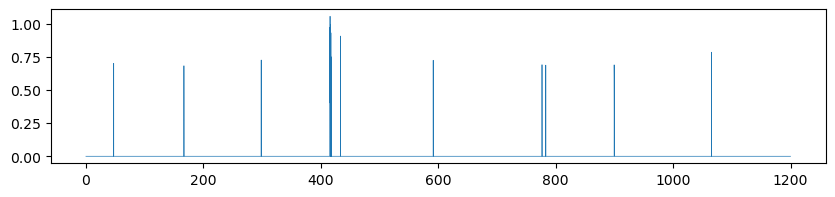

Time (s)        0    1    2    3    4    ...
--------------  ---  ---  ---  ---  ---  -----
0.0             0.0  0.0  0.0  0.0  0.0  ...
0.033333333     0.0  0.0  0.0  0.0  0.0  ...
0.066666667     0.0  0.0  0.0  0.0  0.0  ...
0.1             0.0  0.0  0.0  0.0  0.0  ...
0.133333333     0.0  0.0  0.0  0.0  0.0  ...
0.166666667     0.0  0.0  0.0  0.0  0.0  ...
0.2             0.0  0.0  0.0  0.0  0.0  ...
...             ...  ...  ...  ...  ...  ...
1199.766666667  0.0  0.0  0.0  0.0  0.0  ...
1199.8          0.0  0.0  0.0  0.0  0.0  ...
1199.833333333  0.0  0.0  0.0  0.0  0.0  ...
1199.866666667  0.0  0.0  0.0  0.0  0.0  ...
1199.9          0.0  0.0  0.0  0.0  0.0  ...
1199.933333333  0.0  0.0  0.0  0.0  0.0  ...
1199.966666667  0.0  0.0  0.0  0.0  0.0  ...
dtype: float32, shape: (36000, 3217)


In [ ]:
position = behavior_data['SpatialSeries']
epochs = behavior_data['Running_laps']
lick = behavior_data['licking']
transients = calcium_data["Deconvolved"]

position_values = np.array(position) 
# 仅缩放位置值：y_new = y_original * 2
scaled_values = position_values * 1  # 位置值从 0-200 → 0-400

# 创建新的 Tsd 对象（时间戳完全不变）
scaled_position = nap.Tsd(
    t=position.times(),  # 原始时间戳不变
    d=scaled_values,     # 缩放后的 NumPy 数组
    time_units='s'
)
position = scaled_position

np.where(transients==np.max(transients))

print_to_log(position)
print_to_log(transients)
print_to_log(epochs)

plt.figure(figsize=(10,2))
plt.plot(transients[1:36000,200], linewidth=0.5)
plt.show()

print(transients)


插入帧数：30 
时间连续性检查：True
首块前插入时间示例：[0.         0.03333333 0.06666667] → 原始首时间：0.0


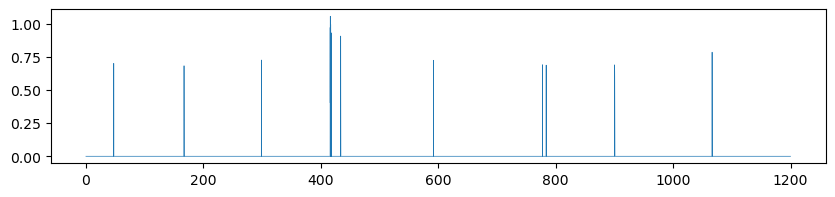

In [ ]:
# 原始数据
original_transients = calcium_data["Deconvolved"]
original_data = original_transients.values  # (36000, 751)
original_times = original_transients.times()
dt = np.diff(original_times).mean()  # 帧间隔 (约 0.0333 秒)

# 参数设置
chunk_size = 3600          # 每个块3600帧
insert_frames = 3          # 每个块前插入3帧
n_chunks = 10              # 总块数 (36000/3600=10)
total_inserts = insert_frames * n_chunks  # 总插入30帧

# 预分配内存（精确尺寸）
new_data = np.zeros((original_data.shape[0] + total_inserts, original_data.shape[1]), dtype=original_data.dtype)
new_times = np.zeros(original_data.shape[0] + total_inserts)

# 索引指针初始化
current_new_idx = 0

for chunk in range(n_chunks):
    # === 插入3帧 ===
    if chunk == 0:
        # 首块前：复制首帧
        insert_values = np.tile(original_data[0], (insert_frames, 1))
        insert_times = np.linspace(0, insert_frames*dt, insert_frames, endpoint=False)
    else:
        # 中间块前：线性插值
        prev_last = original_data[chunk*chunk_size - 1]
        curr_first = original_data[chunk*chunk_size]
        insert_values = np.linspace(prev_last, curr_first, insert_frames+2)[1:-1]
        
        # 关键修复：精确生成3个时间戳
        insert_times = np.linspace(
            start=current_new_time + dt,
            stop=current_new_time + (insert_frames+1)*dt,
            num=insert_frames,
            endpoint=False
        )
    
    # 严格验证时间戳数量
    assert len(insert_times) == insert_frames, f"插入时间戳数量错误：{len(insert_times)} 应等于 {insert_frames}"
    
    # 填充插入数据
    new_data[current_new_idx:current_new_idx+insert_frames] = insert_values
    new_times[current_new_idx:current_new_idx+insert_frames] = insert_times
    current_new_idx += insert_frames

    # === 写入当前块数据 ===
    chunk_start = chunk * chunk_size
    chunk_end = chunk_start + chunk_size
    
    # 生成精确3600个时间戳（使用相对时间计算）
    chunk_times = new_times[current_new_idx-1] + dt + np.arange(chunk_size)*dt
    
    new_data[current_new_idx:current_new_idx+chunk_size] = original_data[chunk_start:chunk_end]
    new_times[current_new_idx:current_new_idx+chunk_size] = chunk_times
    current_new_idx += chunk_size
    current_new_time = new_times[current_new_idx-1]  # 记录当前时间指针

# 最终维度验证
assert len(new_times) == 36030, f"时间戳总数应为36030，实际为{len(new_times)}"
assert new_data.shape[0] == 36030, f"数据维度应为36030，实际为{new_data.shape[0]}"

# 创建新TsdFrame
new_transients = nap.TsdFrame(
    t=new_times,
    d=new_data,
    time_units='s',
    columns=original_transients.columns
)
# ===== 验证 =====
print(f"插入帧数：{total_inserts} ")
print(f"时间连续性检查：{np.allclose(np.diff(new_times), dt, atol=1e-6)}")  # 应返回True
print(f"首块前插入时间示例：{new_times[:3]} → 原始首时间：{original_times[0]}")

plt.figure(figsize=(10,2))
plt.plot(new_transients[1:36000,200], linewidth=0.5)
plt.show()



# Interpolate behavioral data

In order to compare neuronal activity to behavior, it would be useful to work with vector of the same size. Fortunately, we have time vectors corresponding to both neuronal activity and behavior so we can perform linear interpolation:

We have now interpolated the position of the mouse to the sampling frequency of our imaging data. Note that there is virtually no difference compared to the orginial signal. If you use a different interpolation method (eg spline or bicubic), it is important to verify it does not introduce some artefacts that could result in erroneous results later on.

# Speed filter

we will identify periods of running (speed > 5 cm.s-1) and focus our analyses on these epochs:

First, we will calculate the velocity

index    start     end
0        0.0       18.889
1        21.92     36.196
2        39.213    54.806
3        57.809    72.894
4        75.959    91.89
5        94.917    109.863
6        112.881   126.826
...      ...       ...
51       1037.499  1064.261
52       1067.267  1094.455
53       1097.476  1119.592
54       1122.637  1144.723
55       1147.749  1171.127
56       1174.153  1190.792
57       1193.792  1219.565
shape: (58, 2), time unit: sec.


d:\anaconda3\envs\PCcaiman\lib\site-packages\pynapple\core\utils.py:196: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Dataset'.
  warnings.warn(


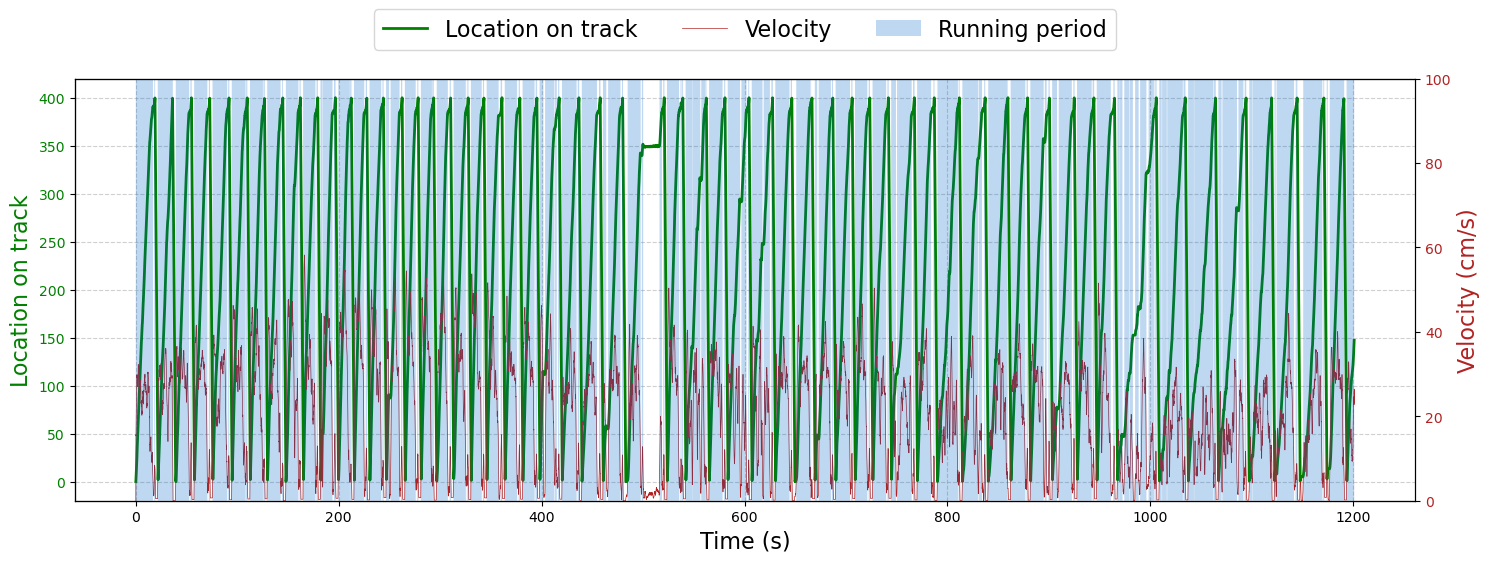

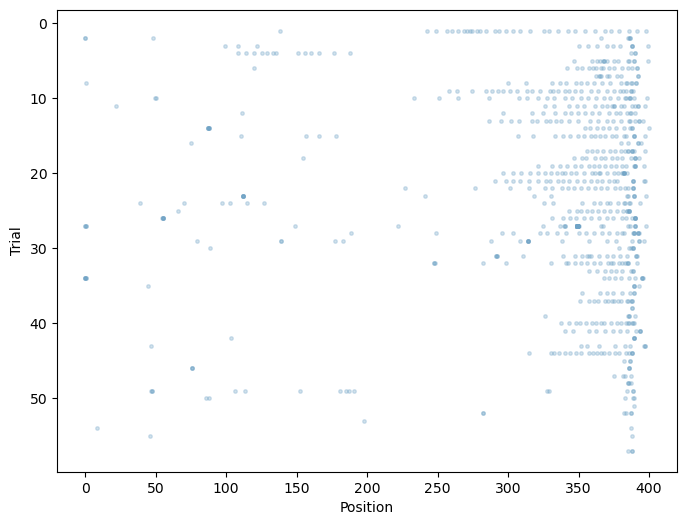

In [ ]:
if add_frames:
    transients = new_transients
    num_frames = 36030
else: num_frames = 36000
    
scale = 1   # temporal scaling for behavioral data

# 2) 缩放位置和舔舐时序（变量名不变）
position = nap.Tsd(
    t=position.times() * scale,
    d=position.values,
    time_units='s'
)
lick = nap.Tsd(
    t=lick.times() * scale,
    d=lick.values,
    time_units='s'
)

# 3) 缩放 epochs —— 保持它是一个 IntervalSet 对象
#    注意：behavior_data['Running_laps'] 原本就是一个 IntervalSet
_orig = behavior_data['Running_laps']
epochs = nap.IntervalSet(
    start=_orig.start * scale,
    end  =_orig.end   * scale
)

interp_func = interp1d(
    position.times(),
    position.values,
    fill_value=(position.values[0], position.values[-1]),
    bounds_error=False
)
tmp = interp_func(transients.times())   # use interpolation function returned by `interp1d`
Filtered_Position = nap.Tsd(
    t=transients.times(),
    d=tmp,
    time_units='s'
)


position_bins = np.linspace(np.min(Filtered_Position.values),
                            np.max(Filtered_Position.values),
                            bin_num + 1)
bin_indices = np.digitize(Filtered_Position.values,
                          position_bins,
                          right=True) - 1
bin_indices = np.clip(bin_indices, 0, bin_num - 1)

bin_indices = pd.Series(bin_indices)


cumulative_position_tmp = []  
print(epochs)
for i in range(0, len(epochs)): 
    temp = position.restrict(epochs[i]) + track_length * i
    cumulative_position_tmp.append(temp)  

cumulative_position_array = np.concatenate(cumulative_position_tmp)
interp_func = interp1d(
    cumulative_position_array.times(),
    cumulative_position_array.values,
    fill_value="extrapolate"
)
tmp = interp_func(transients.times())   # use interpolation function returned by `interp1d`
cumulative_position = nap.Tsd(
    t=transients.times(),
    d=tmp,
    time_units='s'
)

velocity = np.array(0)
for i in range(1, len(cumulative_position.times())):
    velocity = np.append(
        velocity,
        abs(cumulative_position.values[i] - cumulative_position.values[i-1]) /
        (cumulative_position.times()[i] - cumulative_position.times()[i-1])
    )

smoothWindowSize = 29
smoothed_middle = np.convolve(
    velocity,
    np.ones(smoothWindowSize, dtype=int),
    'valid'
) / smoothWindowSize   
r = np.arange(1, smoothWindowSize-1, 2)
start = np.cumsum(velocity[:smoothWindowSize-1])[::2] / r
stop = (np.cumsum(velocity[:-smoothWindowSize:-1])[::2] / r)[::-1]
velocity = np.concatenate((start, smoothed_middle, stop))

min_speed_threshold = 5  # cm.s-1
is_running = (velocity > min_speed_threshold)

running_index = Filtered_Position * 0
running_index[is_running] = track_length

# --- 使用 Matplotlib 绘制三Y轴图表 ---

# 1. 创建图形和左侧的主坐标轴 (ax1)
fig, ax1 = plt.subplots(figsize=(15, 6)) # 稍微增加高度以容纳更多轴标签

# --- 轴1 (左侧): 绘制位置 ---
color_position = 'green'
ax1.plot(transients.times(), Filtered_Position.values, 
         color=color_position, linewidth=2, label='Location on track') # 加粗一点以便观察
ax1.set_xlabel('Time (s)', fontsize=16)
ax1.set_ylabel('Location on track', fontsize=16, color=color_position)
ax1.tick_params(axis='y', labelcolor=color_position)
ax1.grid(True, linestyle='--', alpha=0.6) # 主网格线


# --- 轴2 (右侧): 绘制速度 (Velocity) ---
ax2 = ax1.twinx() # 创建第一个右侧轴
color_velocity = 'firebrick'
ax2.plot(transients.times(), velocity, 
         color=color_velocity, linewidth=0.5, label='Velocity', alpha = 1)
ax2.set_ylabel('Velocity (cm/s)', fontsize=16, color=color_velocity)
ax2.tick_params(axis='y', labelcolor=color_velocity)
ax2.set_ylim(0, 100) # 按要求设置范围 0-40


# --- 轴3 (最右侧): 绘制跑步时段的填充区域 ---
ax3 = ax1.twinx() # 再创建一个右侧轴
# 关键步骤: 将第三个轴的脊柱 (spine) 向右移动，以防止与 ax2 重叠
# 'outward' 表示向外，60 是移动的点数 (points)，可以根据需要调整
ax3.spines['right'].set_position(('outward', 100))

# 准备填充数据 (和上次一样)
y_fill_height = 400 # 假设位置Y轴最大为400
fill_values = np.zeros_like(transients.times(), dtype=float)
fill_values[is_running] = y_fill_height

# 在第三个轴上绘制填充区域
fill_color_running = (0/255, 100/255, 200/255, 0.25)
ax3.fill_between(transients.times(), fill_values, 0,
                 facecolor=fill_color_running, label='Running period', zorder=0) # zorder=0 确保它在最底层
ax3.set_ylim(0, y_fill_height) # 确保填充区域的轴范围正确
ax3.set_yticks([]) # 这个轴只是背景，不需要刻度


# --- 统一管理三个图例 ---
# 从三个轴分别获取 "handles" 和 "labels"
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()

# 合并并创建图例
fig.legend(handles=h1 + h2 + h3, labels=l1 + l2 + l3, 
           loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=3, fancybox=True, fontsize=16)

# 调整布局以防止图例或标签被裁剪
fig.tight_layout(rect=[0, 0.05, 1, 0.9]) # 调整rect为图例和底部留出空间

# 显示图形
if slice_no == 1:
    fig.savefig(output_path / "positions_and_velocity.png", dpi=300)
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
for n in range(len(epochs)-1, 0, -1):
    lick_times = lick.restrict(epochs[n]).times()
    position_times = position.restrict(epochs[n]).times()
    position_values = position.restrict(epochs[n]).values
    lick_positions = np.interp(lick_times, position_times, position_values)
    ax.plot(lick_positions, np.full_like(lick_positions, n),
            '.', markersize=5, color='#6FA3C6', alpha=0.3)
ax.invert_yaxis()
ax.set_xlabel('Position')
ax.set_ylabel('Trial')

if slice_no == 1:
    fig.savefig(output_path / "lick_positions_by_trial.png", dpi=300)

plt.show()

initial_tuning_curves = nap.compute_1d_tuning_curves_continuous(
    transients[is_running],
    feature=Filtered_Position[is_running],
    nb_bins=bin_num,
)
smoothcurves = smoothAngularTuningCurves(initial_tuning_curves, sigma=1)



### Licking selectivity

In [ ]:
lick_pos = position.interpolate(lick)

reward_location = 380
unreward_location = reward_location - 200
area_size = 10

pre_reward = (lick_pos.values >= (reward_location-area_size)) & (lick_pos.values < reward_location)
unrewarded = (lick_pos.values >= (unreward_location)) & (lick_pos.values < (unreward_location + area_size))

num_pre = np.sum(pre_reward)
num_un = np.sum(unrewarded)

selectivity = (num_pre - num_un) / (num_pre + num_un) if num_pre + num_un > 0 else np.nan

print(f"Licking selectivity:{selectivity:.3f}")

Licking selectivity:0.870


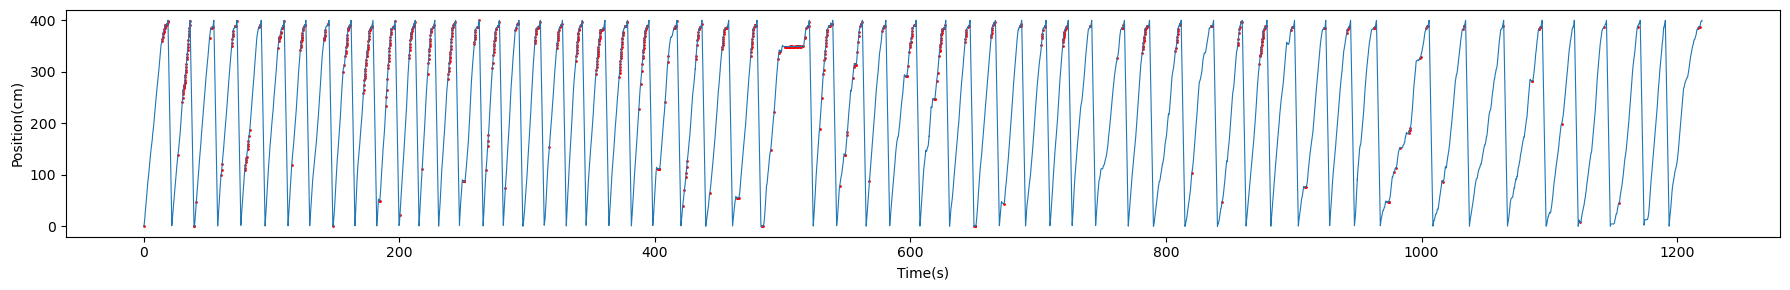

In [ ]:
plt.figure(figsize=(18,3))
plt.plot(position.index, position.values,linewidth=0.8, label='Position')

plt.scatter(lick_pos.index, lick_pos.values, color = 'red', s = 1, label = 'Licking')

plt.xlabel("Time(s)")
plt.ylabel("Position(cm)")
# plt.legend()
plt.tight_layout()
plt.show()

We have now slectively extracted periods where the mouse running speed > 5cm/s.

### Find place fields

FilterField_thresholdRatio is set as 0.25
FilterMean_threshold is set as 5
FilterTime_thresholdRatio is set as 0.33


parallel filtering neurons: 100%|██████████| 2690/2690 [00:34<00:00, 78.13it/s]


After filter 
74 neurons pass



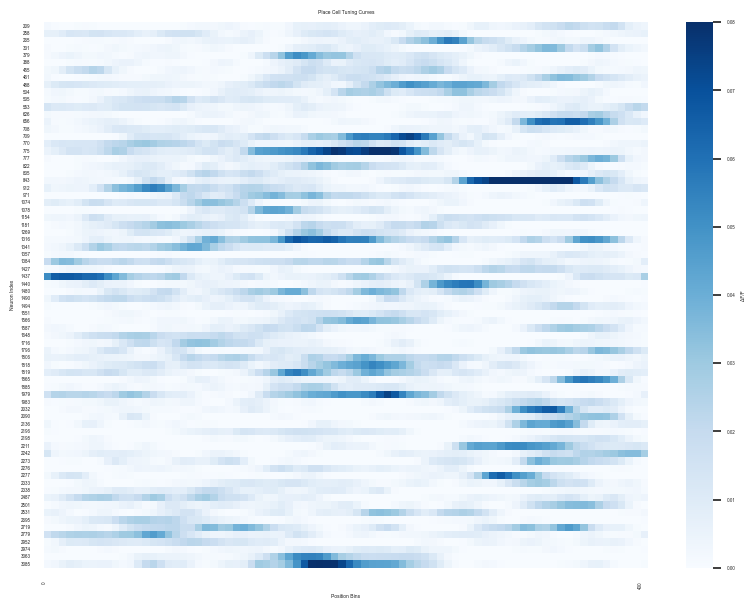

MemoryError: Unable to allocate 107. MiB for an array with shape (28064, 1000) and data type float32

In [ ]:
bin_num = 80
FilterField_thresholdRatio = 0.25
FilterMean_threshold = 7  # The mean in-field ΔF/F value must be more than "FilterMean_threshold" times the mean out-of-field ΔF/F value. 
FilterTime_thresholdRatio = 0.33 # Significant calcium transients must be present “FilterTime_thresholdRatio” of the time the mouse spent in the place field

print_to_log(f"FilterField_thresholdRatio is set as {FilterField_thresholdRatio}\nFilterMean_threshold is set as {FilterMean_threshold}\nFilterTime_thresholdRatio is set as {FilterTime_thresholdRatio}")

from joblib import Parallel, delayed
from tqdm import tqdm

# ✅ 先定义封装函数
def process_neuron_for_place_cell(
    neuro_idx,
    tuning_curves,
    transients,
    Filtered_Position,
    epochs,
    bin_indices,
    num_frames,
    FilterField_thresholdRatio,
    FilterMean_threshold,
    FilterTime_thresholdRatio
):
    if place_cell_identification(
        neuron_idx=neuro_idx,
        tuning_curves=tuning_curves,
        transients=transients,
        Filtered_Position=Filtered_Position,
        epochs=epochs,
        bin_indices=bin_indices,
        num_frames=num_frames,
        FilterField_thresholdRatio=FilterField_thresholdRatio,
        FilterMean_threshold=FilterMean_threshold,
        FilterTime_thresholdRatio=FilterTime_thresholdRatio
    ):
        return neuro_idx  # 通过筛选，返回该神经元索引
    else:
        return None  # 未通过筛选，返回 None


# ======================
# 并行处理神经元筛选
# ======================

n_jobs = 18  # 可调整为你的 CPU 核数，比如 4, 6, 8, ...

potential_place_cells = Parallel(n_jobs=n_jobs)(
    delayed(process_neuron_for_place_cell)(
        neuro_idx,
        smoothcurves,
        transients,
        Filtered_Position,
        epochs,
        bin_indices,
        num_frames,
        FilterField_thresholdRatio,
        FilterMean_threshold,
        FilterTime_thresholdRatio
    )
    for neuro_idx in tqdm(Valid_ROIs, desc="parallel filtering neurons")
)

# 过滤掉 None，只保留通过筛选的神经元索引
potential_place_cells = [neuro_idx for neuro_idx in potential_place_cells if neuro_idx is not None]

print_to_log(f"After filter \n{len(potential_place_cells)} neurons pass\n")

temp_curve = smoothcurves.iloc[:, potential_place_cells]
plot_tcurve(temp_curve)

# Significance testing: deriving a p-value from shuffled surrogates
# How confident can we be with our result? Note that if the mouse displayed heterogeneous exploration patterns, 
# or neuron #4 fired only sparsely, we could very obtain this result by chance. One way to address this issue and assess our confidence level, 
# we can shuffle the actual neuronal activity so that the temporal relationship to behavior is lost:
place_cells_index = FilterShuffle_parallel(
    potential_place_cells, 
    transients, 
    is_running = is_running, 
    Filtered_Position = Filtered_Position, 
    epochs=epochs, 
    bin_indices= bin_indices,
    nsample = 1000, window = 50, bin_num = 80, num_frames=num_frames,
    FilterField_thresholdRatio = FilterField_thresholdRatio,
    FilterMean_threshold = FilterMean_threshold,
    FilterTime_thresholdRatio = FilterTime_thresholdRatio)

print_to_log(f"Significance testing\n{len(place_cells_index)} neurons pass\n")
# FinalCurve = smoothcurves.iloc[:, place_cells_index]
# plot_tcurve(FinalCurve)
print(place_cells_index)

Sorted_index = organize_place_cells_by_peak(smoothcurves,place_cell_indices=place_cells_index)
FinalCurve_sorted = smoothcurves.iloc[:, Sorted_index]
plot_tcurve(FinalCurve_sorted)



Re-write iscell file and Save log

We can then compute the average and standard deviation of the shuffled tuning curves, and use these values to z-score our actual tuning curve:

Then we can count the number of active versus inactive periods for each discretized location. This will result in a joint probability distribution (= tuning curve). At the same time, we can assess the overall linear track occupancy:

Silent cells

In [ ]:
dff = calcium_data['RoiResponseSeries']
raw_dff = np.array(dff)
noise_levels = calculate_noise_levels(raw_dff.T, frame_rate)
meadian_noise_level = np.median(noise_levels)
print(meadian_noise_level)
p95_pct = np.nanpercentile(raw_dff*100, 95 , axis=0)
p95_in_cells = p95_pct[Valid_ROIs]
noise_in_cells = noise_levels[Valid_ROIs]


1.9699991


In [ ]:
if mean_img is not None:
    I_local = np.array([roi_local_intensity(mean_img, s) for s in stat])
    I_pct = 100.0 * (I_local - np.nanmin(I_local)) / (np.nanmax(I_local)-np.nanmin(I_local) + 1e-9)
else:
    I_local = np.full(len(Primary_cell_index), np.nan)
    I_pct = np.full(len(Primary_cell_index), np.nan)

cell_intesity_place = I_local[place_cells_index]
intensity_threshold = np.percentile(cell_intesity_place, 5)  # Q1
intensity_threshold


87.53477478027344

In [ ]:
# —— 固定标准事件幅度为 8% ΔF/F ——
A_std_pct = 50  # 单位：%

# —— 可探测性判定（保持原逻辑）——
k = 3 # 目标 SNR 门槛；若过宽松可提到 3.5–4.0
nz = noise_levels.astype(float).copy()  # 你的噪声（单位：%）

# 动态噪声下限，避免 0 或极小值导致 SNR 畸高
bad = (~np.isfinite(nz)) | (nz <= 0)
if np.any(bad):
    base = np.nanpercentile(nz[~bad], 1) if np.any(~bad) else 0.05  # 1分位 or 0.05%
    nz[bad] = max(0.05, float(base))

detectability_ok = (A_std_pct >= k * nz)  # 形状：(N,)
high_detect_cell = detectability_ok & (I_local>intensity_threshold)
# 可选：也看下 Valid_ROIs 子集
valid_idx = np.unique(np.asarray(Valid_ROIs, int))
valid_idx = valid_idx[(valid_idx >= 0) & (valid_idx < nz.size)]



print(f"[固定A_std] A_std = {A_std_pct:.2f}% ΔF/F")
print(f"detectability_ok 比例（全体ROI）：{high_detect_cell.mean():.2f}")
if valid_idx.size > 0:
    print(f"detectability_ok 比例（Valid_ROIs子集）：{high_detect_cell[valid_idx].mean():.2f}")


[固定A_std] A_std = 50.00% ΔF/F
detectability_ok 比例（全体ROI）：0.77
detectability_ok 比例（Valid_ROIs子集）：0.80


In [ ]:
submask = high_detect_cell[valid_idx]          # 形状：(len(valid_idx),)

Valid_ROIs_SNR = valid_idx[submask]
print(f"合格细胞数：{len(Valid_ROIs_SNR)}")

合格细胞数：2153


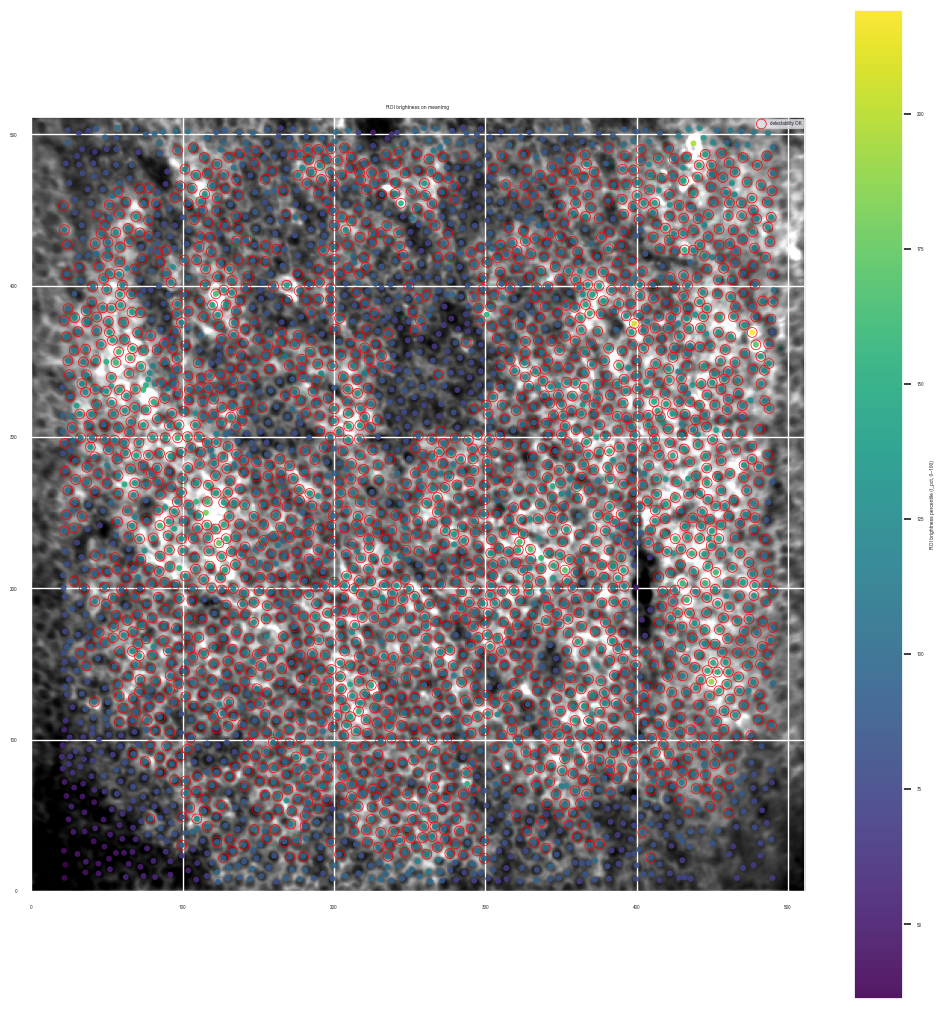

In [ ]:

plot_roi_brightness_heatmap(mean_img, stat, I_local, ok_idx=Valid_ROIs_SNR, title_suffix="")


0.6903723


100%|██████████| 200/200 [00:00<00:00, 4428.97it/s]


200
[104, 123, 151, 167, 183, 195, 218, 222, 245, 268, 271, 283, 290, 296, 299, 300, 305, 312, 329, 344, 354, 365, 374, 377, 390, 393, 395, 398, 419, 421, 446, 454, 467, 469, 475, 482, 507, 523, 528, 542, 575, 613, 616, 620, 629, 634, 652, 672, 691, 696, 702, 712, 730, 736, 762, 789, 806, 817, 829, 846, 847, 848, 885, 887, 889, 892, 893, 915, 926, 932, 937, 939, 940, 942, 947, 959, 967, 969, 1001, 1014, 1041, 1066, 1075, 1097, 1112, 1216, 1228, 1233, 1244, 1283, 1285, 1320, 1353, 1358, 1365, 1379, 1429, 1430, 1452, 1456, 1471, 1475, 1487, 1545, 1548, 1554, 1575, 1588, 1589, 1630, 1703, 1712, 1715, 1754, 1771, 1788, 1832, 1857, 1917, 1921, 1944, 1949, 1972, 1975, 2035, 2052, 2080, 2098, 2133, 2153, 2158, 2184, 2190, 2204, 2206, 2212, 2266, 2270, 2284, 2305, 2314, 2336, 2343, 2356, 2399, 2402, 2405, 2410, 2452, 2477, 2511, 2523, 2524, 2532, 2534, 2550, 2555, 2588, 2596, 2603, 2626, 2644, 2654, 2655, 2664, 2686, 2707, 2726, 2732, 2734, 2739, 2753, 2764, 2768, 2772, 2783, 2812, 2824, 2868,

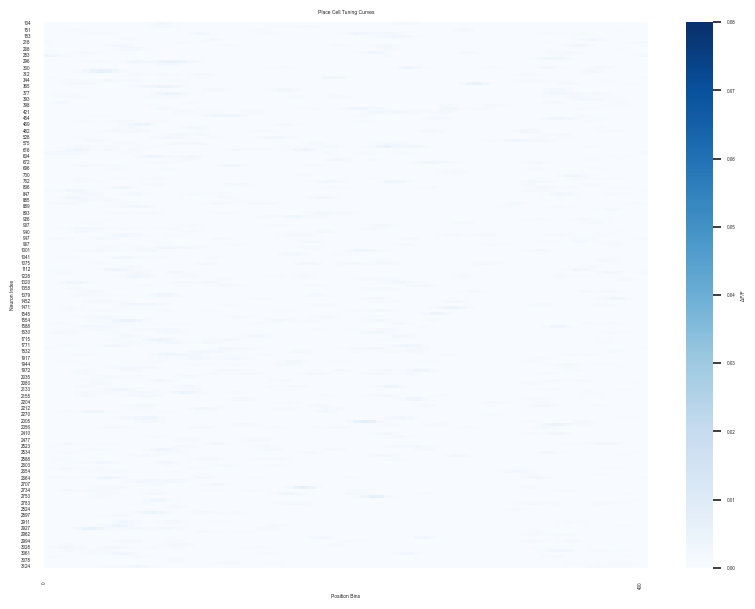

In [ ]:
good_cells = Valid_ROIs_SNR
peak_activity = np.max(transients, axis=0)
median_peak = np.median(peak_activity)
print(median_peak)

sig_transients = np.array(transients.values)
sig_transients_bool = np.array(sig_transients, dtype=bool)
transients_total_frames = transients.shape[0]
potential_silent_cells_index = []
for neuron_idx in good_cells:
    sig_frames = np.sum(sig_transients_bool[:,neuron_idx])
    sig_frames_ratio = sig_frames/transients_total_frames
    if sig_frames_ratio < 0.001: 
        potential_silent_cells_index.append(neuron_idx)

silent_cells_index = []
for neuron_idx in tqdm(potential_silent_cells_index):
    peak = np.max(transients[:,neuron_idx])
    if peak < median_peak: 
        silent_cells_index.append(neuron_idx)


print(len(potential_silent_cells_index))
print(potential_silent_cells_index)

SilentCurve1 = smoothcurves.iloc[:, potential_silent_cells_index]

print_to_log(f"The number of silent cells is: {len(silent_cells_index)}")
print_to_log(silent_cells_index)

SilentCurve2 = smoothcurves.iloc[:, silent_cells_index]
plot_tcurve(SilentCurve2, save_name=f"Silent Cells_{slice_no}")


Non-place cells

100%|██████████| 51/51 [00:00<00:00, 10164.39it/s]


0.008451290591174021 0.02704690535664724


100%|██████████| 2690/2690 [00:00<00:00, 25775.72it/s]


453
The number of nonplace cells is:405
Heatmap saved as Non place cells_1.png


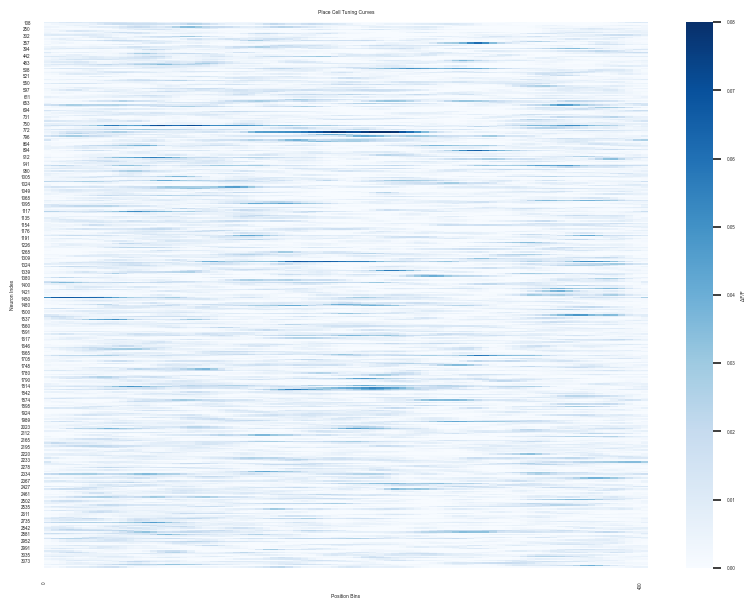

In [ ]:
potential_nonplace_cells_index = []
nonplace_cells_index = []

try:
    firing_rate = []
    for neuron_idx in tqdm(place_cells_index):
        sig_frames = np.sum(sig_transients_bool[:, neuron_idx])
        sig_frames_ratio = sig_frames / transients_total_frames
        firing_rate.append(sig_frames_ratio)
        
    data = np.array(firing_rate)
    q1 = np.percentile(data, 5)  # Q1
    q3 = np.percentile(data, 95)  # Q3
    
    print(q1,q3)

    transients_total_frames = transients.shape[0]

    for neuron_idx in tqdm(Valid_ROIs):
        sig_frames = np.sum(sig_transients_bool[:,neuron_idx])
        sig_frames_ratio = sig_frames/transients_total_frames
        if max(q1,0.0001) < sig_frames_ratio :
            potential_nonplace_cells_index.append(neuron_idx)
    print(len(potential_nonplace_cells_index))

    nonplace_cells_index = [index for index in potential_nonplace_cells_index if index not in place_cells_index]

except Exception as e:
    print_to_log(e)


print_to_log(f"The number of nonplace cells is:{len(nonplace_cells_index)}")
#nonpcCurve1 = smoothcurves.iloc[:, potential_nonplace_cells_index]
#plot_tcurve(nonpcCurve1)

nonpcCurve2 = smoothcurves.iloc[:, nonplace_cells_index]
plot_tcurve(nonpcCurve2, save_name=f"Non place cells_{slice_no}")

In [ ]:
iscell_path = source / "suite2p" / "plane0" / "iscell.npy"

WriteIscell(place_cells_index, source, f"place cells_slice{slice_no}")
WriteIscell(nonplace_cells_index, source, f"nonPC_slice{slice_no}")
WriteIscell(silent_cells_index, source, f"silent cells_slice{slice_no}")

place cells_slice1.npy is written
nonPC_slice1.npy is written
silent cells_slice1.npy is written


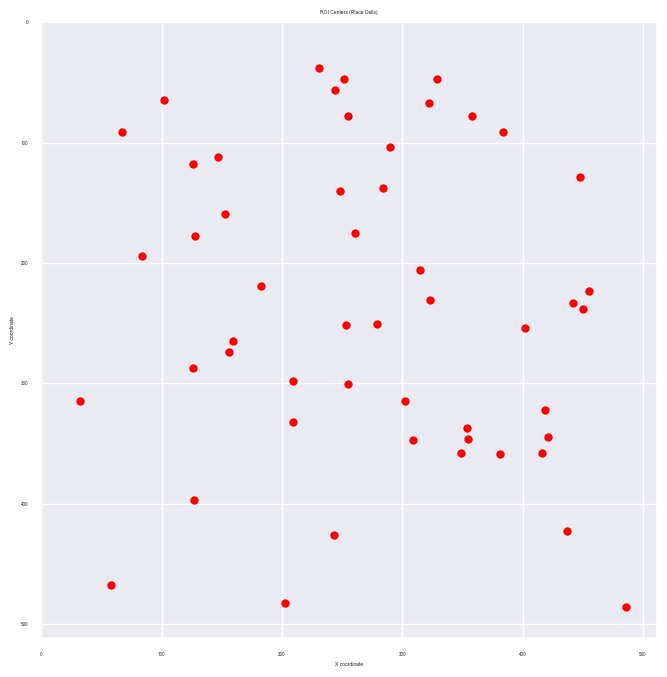

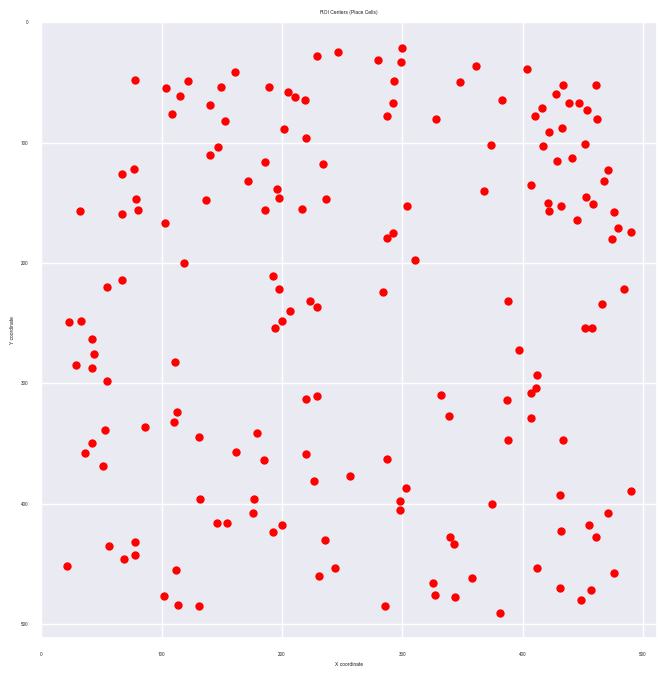

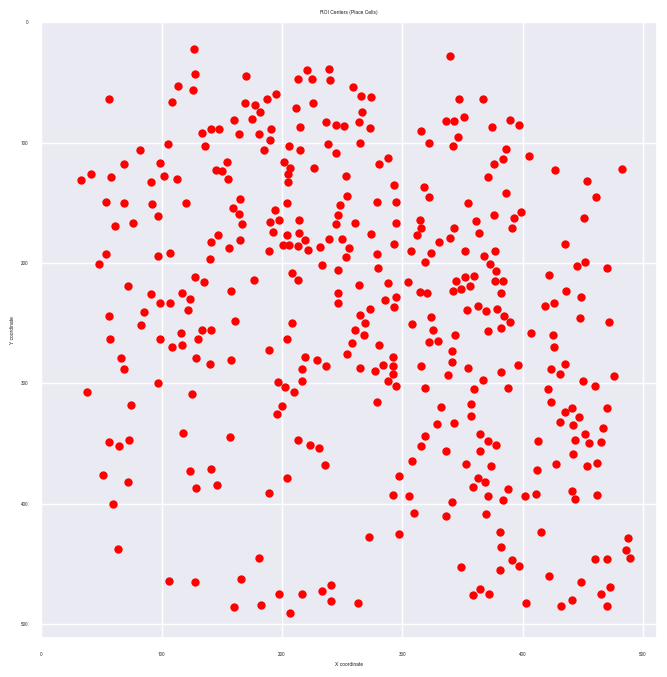

In [ ]:
placeCells_observe= np.load(output_path / f"place cells_slice{slice_no}.npy")
silentCells_observe= np.load(output_path / f"silent cells_slice{slice_no}.npy")
nonplaceCells_observe= np.load(output_path / f"nonPC_slice{slice_no}.npy")

visualize_location(placeCells_observe, stat)
visualize_location(silentCells_observe, stat)
visualize_location(nonplaceCells_observe, stat)


In [ ]:
xxx

NameError: name 'xxx' is not defined

nonPC_slice1.npy
place cells_slice1.npy
silent cells_slice1.npy
[209, 258, 265, 331, 379, 388, 455, 461, 534, 553, 626, 656, 709, 777, 835, 843, 971, 1074, 1078, 1181, 1269, 1341, 1357, 1427, 1440, 1490, 1551, 1566, 1587, 1648, 1716, 1796, 1865, 1885, 1979, 1983, 2032, 2090, 2136, 2196, 2198, 2211, 2273, 2276, 2277, 2531, 2695, 2719, 2974, 3063, 3085]
Appended number of place cells is: 51
Appended number of silent cells is: 173
Appended number of nonplace cells is: 405
place_cells_append.npy is written
nonplace_cells_append.npy is written
silent_cells_append.npy is written
Heatmap saved as place_cells_append.png


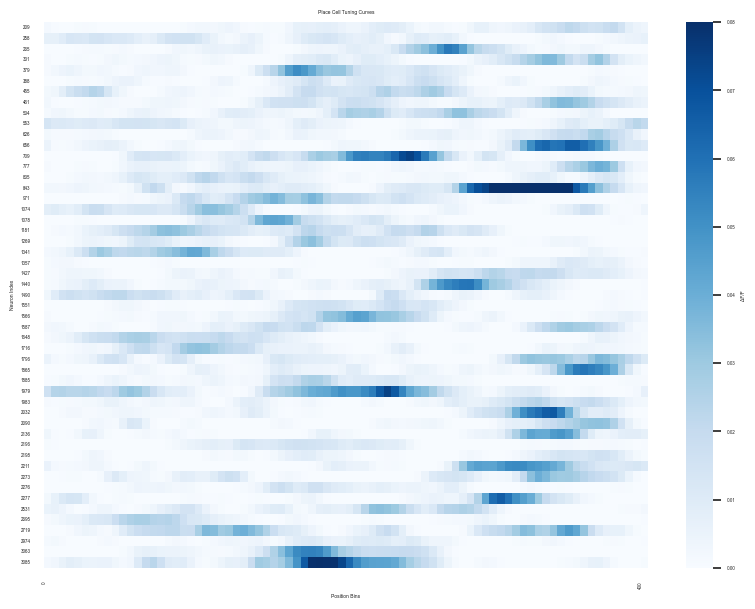

Heatmap saved as Sorted place cells append.png


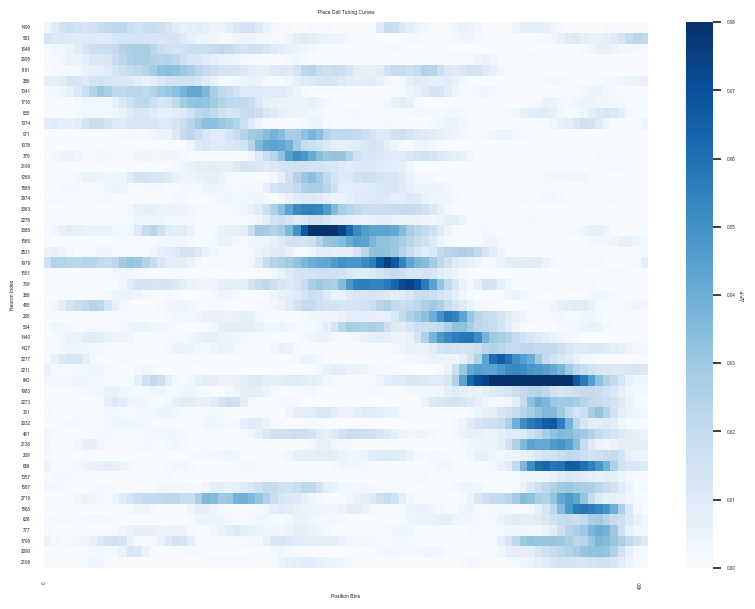

In [ ]:
def find_slices(filename, type):
    """从文件名中提取rep后的数字"""
    match = re.search(r'slice', filename)
    type_match = re.search(rf'{type}', filename)

    if match != None and type_match != None:
        # return int(match.group(1)) if match else 0
        return True

def get_index(file_list, output_path):
    result = []
    for file_name in file_list:
        file_path = output_path / f"{file_name}"
        try:
            data = np.load(file_name)
            valid_indices = np.where(data[:, 0] == 1)[0].tolist()
            result.extend(valid_indices)
        except Exception as e:
            print(f"Error in {file_path}: {e}")
    return result

place_cells_append = []
nonplace_cells_append = []
silent_cells_append = []
for f in Path(output_path).glob("*.npy"):
    if find_slices(filename=f.name, type="place cell"):
        print(f.name)
        place_cells_append.append(f)

    elif find_slices(filename=f.name, type="nonPC"):
        nonplace_cells_append.append(f)
        print(f.name)

    elif find_slices(filename=f.name, type="silent"):
        silent_cells_append.append(f)
        print(f.name)

place_cells_append_index = get_index(place_cells_append, output_path=output_path)
nonplace_cells_append_index = get_index(nonplace_cells_append, output_path=output_path)
silent_cells_append_index = get_index(silent_cells_append, output_path=output_path)

print_to_log(place_cells_append_index)
print_to_log(f"Appended number of place cells is: {len(place_cells_append_index)}")
print_to_log(f"Appended number of silent cells is: {len(silent_cells_append_index)}")
print_to_log(f"Appended number of nonplace cells is: {len(nonplace_cells_append_index)}")

WriteIscell(place_cells_append_index, source, "place_cells_append")
WriteIscell(nonplace_cells_append_index, source, "nonplace_cells_append")
WriteIscell(silent_cells_append_index, source, "silent_cells_append")

place_cells_append_curve = smoothcurves.iloc[:, place_cells_append_index]
plot_tcurve(place_cells_append_curve, save_name=f"place_cells_append")

Sorted_index_append = organize_place_cells_by_peak(smoothcurves,place_cell_indices=place_cells_append_index)
place_cells_append_curve_final = smoothcurves.iloc[:, Sorted_index_append]
plot_tcurve(place_cells_append_curve_final, save_name="Sorted place cells append")


In [ ]:
all_tuning_curves = []
for epoch in range(0, len(epochs)):

    current_position = Filtered_Position.restrict(epochs[epoch])
    if len(current_position) == 0 or np.all(np.isnan(current_position.values)):
        print(f"Epoch {epoch}: Filtered_Position 数据为空或无效，跳过。")
        continue

    tuning_curves = nap.compute_1d_tuning_curves_continuous(
        transients[is_running], feature=Filtered_Position[is_running], nb_bins=bin_num, ep=epochs[epoch]
    )
    smoothcurves_temp = smoothAngularTuningCurves(tuning_curves, sigma=1)
    all_tuning_curves.append(smoothcurves_temp)
# 定义保存目录
save_directory = output_path / f"nonplace cells_append, n={len(nonplace_cells_append_index)}"

os.makedirs(save_directory, exist_ok=True)

# 使用 joblib 进行并行处理
Parallel(n_jobs=18)(
    delayed(generate_and_save_heatmap)(neuron, all_tuning_curves, save_directory)
    for neuron in nonplace_cells_append_index
)

# 定义保存目录
save_directory = output_path / f"place cells_append, n={len(place_cells_append_index)}"

os.makedirs(save_directory, exist_ok=True)

# 使用 joblib 进行并行处理
Parallel(n_jobs=18)(
    delayed(generate_and_save_heatmap)(neuron, all_tuning_curves, save_directory)
    for neuron in place_cells_append_index
)

d:\anaconda3\envs\PCcaiman\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\anaconda3\envs\PCcaiman\lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

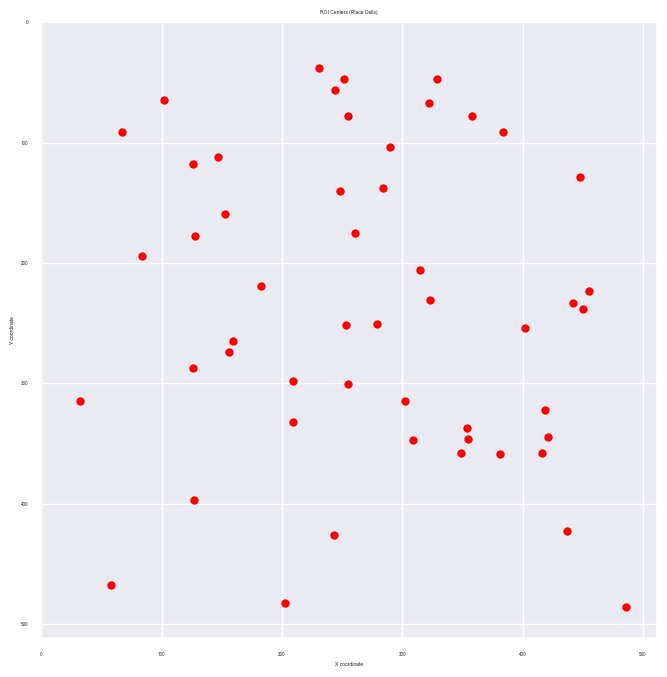

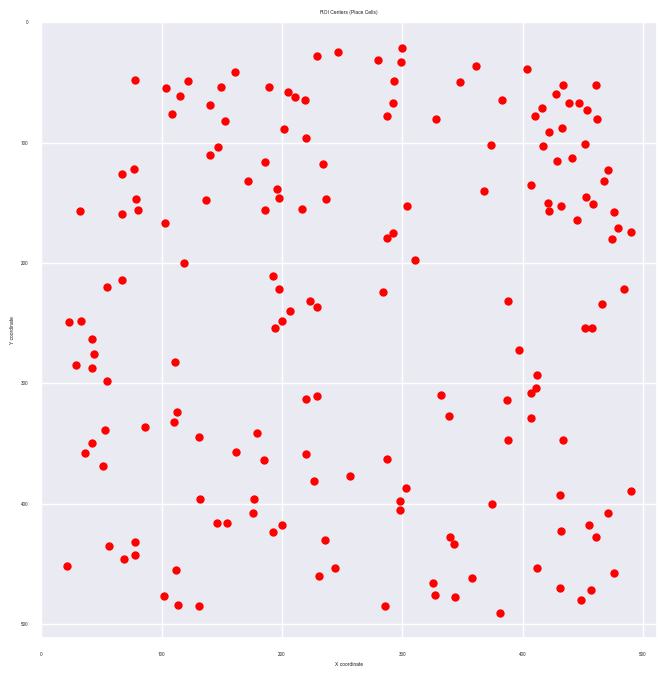

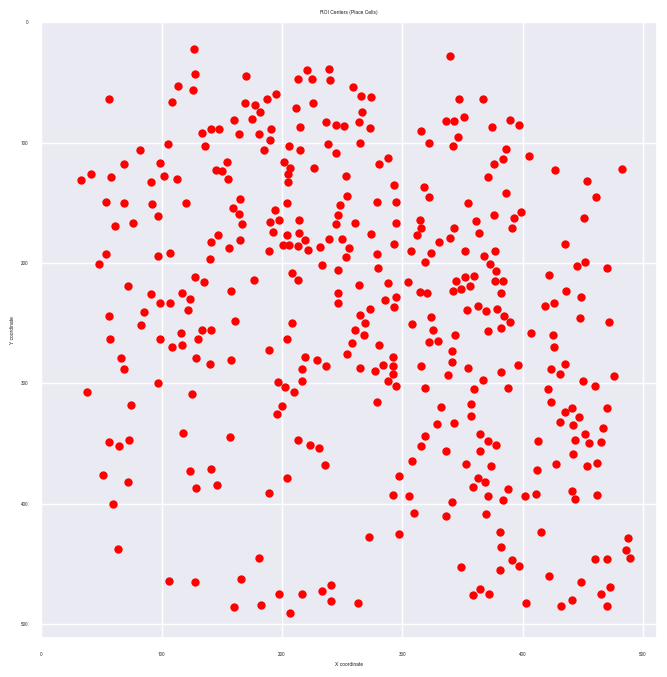

In [ ]:
placeCells_observe= np.load(output_path / f"place_cells_append.npy")
silentCells_observe= np.load(output_path / f"silent_cells_append.npy")
nonplaceCells_observe= np.load(output_path / f"nonplace_cells_append.npy")

visualize_location(placeCells_observe, stat)
visualize_location(silentCells_observe, stat)
visualize_location(nonplaceCells_observe, stat)

In [ ]:
def select_subset(index, num, type):
    if len(index) < num:
        print_to_log(f"⚠️ {type} 列表中只有 {len(index)} 个元素，不足 {num} 个，无法抽取，跳过筛选。")
        return
    subset = random.sample(index, num)

    print_to_log(subset)



    print_to_log(f"Selected number of {type} is: {num}")
    WriteIscell(subset, source, f"{type}_subset")
# 先筛选 silent cells（不管有没有 place cell 都执行）
select_subset(silent_cells_append_index, 300, "silent_cells")

# 检查 place_cells_index 是否为空（即没有 place cell）
if len(place_cells_append_index) == 0:
    print_to_log("⚠️ 没有检测到 place cell（place_cells_index 为空），跳过 nonplace cell 筛选步骤。")
else:
    # 如果有 place cell，则继续筛选 place_cells（比如 300 个）
    select_subset(place_cells_append_index, 300, "place_cells")
    
    # 并且也继续筛选 nonplace_cells
    select_subset(nonplace_cells_append_index, 300, "nonplace_cells")

⚠️ silent_cells 列表中只有 173 个元素，不足 300 个，无法抽取，跳过筛选。
⚠️ place_cells 列表中只有 51 个元素，不足 300 个，无法抽取，跳过筛选。
[1458, 3035, 1489, 1257, 991, 822, 1620, 2195, 623, 2344, 2460, 1485, 2242, 1985, 1927, 811, 579, 689, 1028, 1849, 2735, 2966, 1339, 1617, 2224, 1131, 1874, 911, 2175, 965, 1322, 3051, 1833, 1145, 2040, 743, 2255, 2952, 2721, 1982, 1787, 1748, 456, 1142, 1669, 1329, 2223, 108, 2413, 2363, 2987, 1380, 608, 2328, 2169, 487, 508, 1730, 2427, 2849, 1018, 1571, 941, 1317, 1335, 2935, 2797, 2842, 750, 747, 2536, 357, 2553, 864, 550, 2023, 1154, 525, 555, 341, 2338, 3030, 700, 1744, 2710, 1310, 775, 1989, 3032, 1749, 2978, 1125, 1094, 1908, 512, 2112, 2333, 276, 1226, 1450, 961, 611, 754, 2017, 511, 1519, 483, 513, 876, 780, 1049, 362, 1624, 3074, 1625, 2393, 1344, 364, 1643, 631, 410, 1384, 2176, 1421, 2851, 768, 1500, 2387, 1527, 1790, 1868, 1912, 351, 1176, 1013, 882, 1268, 228, 2499, 2213, 828, 1646, 1479, 1068, 1580, 486, 653, 1345, 1783, 873, 1141, 1155, 2461, 2220, 2951, 2119, 1818, 2323, 

peak = 0.00782396385702886
baseline = 0.0
potential fields boundary is [32, 32, 34, 45, 50, 50, 75, 77]
FilterField pass
Identified 2 place fields: [(34, 46), (75, 78)]
field 0: mean_in = 0.004288317601872847, mean_out = 0.00043981927775150326
FilterMean for field 0 pass
Field 0: traversals = 7, threshold = 19.14
FilterTime for field 0 not pass
field 1: mean_in = 0.003028236839849784, mean_out = 0.00043981927775150326
FilterMean for field 1 not pass
P = 0.0
FilterShuffle pass
spatial information: 0.7749061546114724


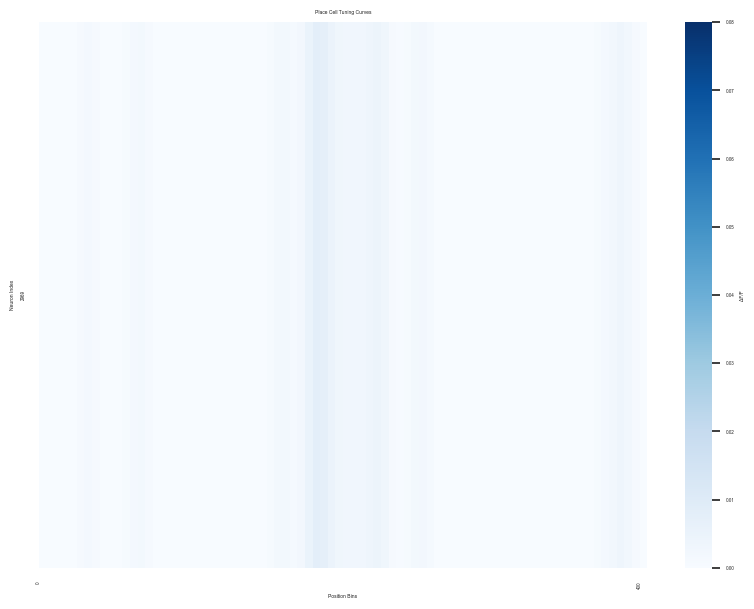

In [ ]:
inspect_cell(2969, tuning_curves=smoothcurves,transients=transients,Filtered_Position=Filtered_Position, epochs=epochs, is_running=is_running, bin_indices=bin_indices, num_frames=num_frames,
             FilterField_thresholdRatio = FilterField_thresholdRatio, FilterMean_threshold = FilterMean_threshold, FilterTime_thresholdRatio = FilterTime_thresholdRatio)

# Evaluate difference in mean DFF and spatial information

ANOVA: F = 276.3909, p = 0.000000

Pairwise comparisons:
nonplace vs place: t = -2.5168, raw p = 0.014523, bonf p = 0.043570
nonplace vs silent: t = 35.2154, raw p = 0.000000, bonf p = 0.000000
place vs silent: t = 13.6725, raw p = 0.000000, bonf p = 0.000000


C:\Users\Ming\AppData\Local\Temp\ipykernel_25452\1785073480.py:30: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



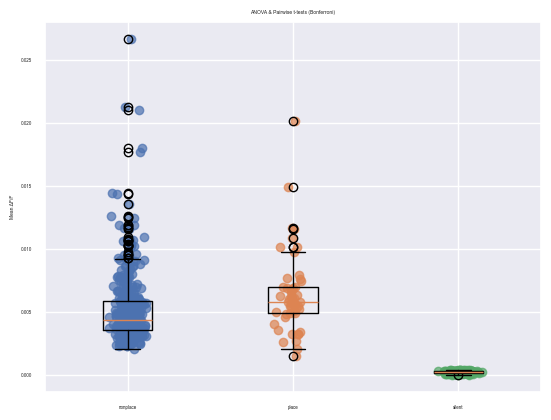

In [ ]:
from scipy.stats import f_oneway, ttest_ind

# 计算DF均值
mean_dff_nonplace = transients[:, nonplace_cells_index].mean(axis=0)
mean_dff_place    = transients[:, place_cells_index].mean(axis=0)
mean_dff_silent   = transients[:, silent_cells_index].mean(axis=0)


groups = [mean_dff_nonplace, mean_dff_place, mean_dff_silent]
labels = ['nonplace', 'place', 'silent']

# 1. ANOVA 检验
F_stat, p_anova = f_oneway(*groups)
print(f"ANOVA: F = {F_stat:.4f}, p = {p_anova:.6f}")

# 2. 两两比较 (Welch t-test + Bonferroni 校正)
pairs = [
    ('nonplace', mean_dff_nonplace, 'place', mean_dff_place),
    ('nonplace', mean_dff_nonplace, 'silent', mean_dff_silent),
    ('place',    mean_dff_place,    'silent', mean_dff_silent),
]
print("\nPairwise comparisons:")
for name1, data1, name2, data2 in pairs:
    t_stat, p_val = ttest_ind(data1, data2, equal_var=False)
    p_bonf = min(p_val * len(pairs), 1.0)
    print(f"{name1} vs {name2}: t = {t_stat:.4f}, raw p = {p_val:.6f}, bonf p = {p_bonf:.6f}")

# 3. 绘图：箱线图 + 抖动散点
plt.figure()
plt.boxplot(groups, labels=labels)
for i, grp in enumerate(groups):
    x = np.random.normal(i+1, 0.04, size=len(grp))
    plt.scatter(x, grp, alpha=0.7)
plt.ylabel('Mean ΔF/F')
plt.title('ANOVA & Pairwise t-tests (Bonferroni)')

plt.show()


In [ ]:
from joblib import Parallel, delayed
import joblib
from contextlib import contextmanager
from tqdm.auto import tqdm
import numpy as np

# —— 参数 ——
n_jobs  = 18
n_bins  = 80
nsample = 1000
window  = 50
temp_all_tuning_curves = nap.compute_1d_tuning_curves_continuous(transients, feature=Filtered_Position, nb_bins=80)
# —— 数据准备（关键：tuning_curves 需为 (N_neurons, n_bins)）——
transients_np = np.asarray(transients)                 # (T, N)
positions_np  = np.asarray(Filtered_Position)          # (T,)
tuning_curves_full = np.asarray(temp_all_tuning_curves).T  # (N, n_bins)

# 可选一致性检查
assert transients_np.shape[0] == positions_np.shape[0]
assert tuning_curves_full.shape[1] == n_bins

def process_neuron(neuron_idx):
    activity = transients_np[:, neuron_idx]
    return compute_spatial_information_with_shuffle(
        neuron_idx, activity, positions_np, tuning_curves_full,
        n_bins=n_bins, nsample=nsample, window=window
    )

# —— joblib × tqdm 集成 —— 
from contextlib import contextmanager
@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_cb = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_cb
        tqdm_object.close()

if __name__ == "__main__":  # Windows 建议加
    with tqdm_joblib(tqdm(total=len(place_cells_index), desc="Spatial info (shuffle)", unit="neuron")):
        place_cells_si = Parallel(n_jobs=n_jobs, prefer="processes")(
            delayed(process_neuron)(idx) for idx in place_cells_index
        )


Spatial info (shuffle):   0%|          | 0/51 [00:00<?, ?neuron/s]

In [ ]:
if __name__ == "__main__":  # Windows 建议加
    with tqdm_joblib(tqdm(total=len(nonplace_cells_index), desc="Spatial info (shuffle)", unit="neuron")):
        nonplace_cells_si = Parallel(n_jobs=n_jobs, prefer="processes")(
            delayed(process_neuron)(idx) for idx in nonplace_cells_index
        )

Spatial info (shuffle):   0%|          | 0/405 [00:00<?, ?neuron/s]

Welch t-test: t = 8.6932, p = 7.9269e-12


C:\Users\Ming\AppData\Local\Temp\ipykernel_25452\1450641746.py:7: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



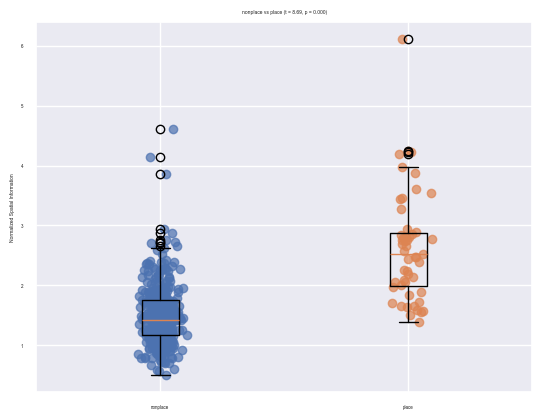

In [ ]:

# 1. Welch t-test
t_stat, p_val = ttest_ind(place_cells_si, nonplace_cells_si, equal_var=False)
print(f"Welch t-test: t = {t_stat:.4f}, p = {p_val:.4e}")

# 2. 绘图：箱线图 + 抖动散点
plt.figure()
plt.boxplot([nonplace_cells_si, place_cells_si], labels=['nonplace', 'place'])
for i, data in enumerate([nonplace_cells_si, place_cells_si]):
    x = np.random.normal(i+1, 0.04, size=len(data))
    plt.scatter(x, data, alpha=0.7)
plt.ylabel('Normalized Spatial Information')
plt.title(f"nonplace vs place (t = {t_stat:.2f}, p = {p_val:.3f})")
plt.show()
